# **Monte Carlo Simulation** - *Vanilla options*
### 1) **Introduction**
####  -- a) *Project Background and Problem Statement*
####  -- b) *Risk-Neutral Monte Carlo Framework*
####  -- c) *Numerical Simulation Methods*
####  -- d) *Monte Carlo Accuracy, Variance Reduction and Greeks*
### 2) **Results**
####  -- a) *Baseline Pricing Results and Absolute Error Analysis*
####  -- b) *Estimator Variance and Standard Error Analysis*
####  -- c) *Delta Analysis*
####  -- d) *Gamma Analysis*
####  -- e) *Theta Analysis*
####  -- f) *Greeks Summary*
### 3) **Interesting observations, problems encountered and discussion of results** 
####  -- a) *Big-Jump versus Step-by-Step Closed-Form Simulation*
####  -- b) *Absolute Pricing Error versus Estimator Variance*
####  -- c) *Numerical Limitations and Practical Considerations*
### 4) **Detailed conclusion** 
### 5) **References**
---

# 1. Introduction

## a) Project Background and Problem Statement

This project investigates the numerical pricing of European plain vanilla call and put options using Monte Carlo simulation under a geometric Brownian motion framework. The analytical Black-Scholes model is used as the benchmark against which the numerical results are evaluated.For a European call option, the terminal payoff is 

$$
P_C(S_T)
=
\max(S_T-K,0),
$$

while the corresponding European put payoff is

$$
P_P(S_T)
=
\max(K-S_T,0),
$$

where $S_T$ denotes the underlying stock price at maturity and $K$ is the strike price.The fundamental pricing problem is to determine the present value of these uncertain future payoffs.Under the risk-neutral pricing framework, the value of a derivative can be expressed as

$$
V(S,t)
=
e^{-r(T-t)}
E^Q
\left[
\text{Payoff}(S_T)
\right],
$$

where $Q$ denotes the risk-neutral probability measure and $r$ is the risk-free interest rate.Therefore, the central numerical objective of this project is to estimate the discounted risk-neutral expected payoff accurately and efficiently.The baseline parameters used throughout the initial analysis are

$$
S_0=100,
\qquad
K=100,
\qquad
r=5\%,
\qquad
\sigma=20\%,
\qquad
T=1 \text{ year}.
$$

The standard Monte Carlo simulations use

$$
N=100{,}000
$$

simulated paths. In the antithetic implementation, 100,000 paired observations are generated using $Z$ and $-Z$. Where time discretisation is required,

$$
252
$$

time steps per year.

The project compares the closed-form GBM transition, Euler-Maruyama and Milstein simulation schemes, evaluates the effect of antithetic variates as a variance-reduction technique, and studies the sensitivity of option values through Delta, Gamma and Theta.The numerical results are compared with the analytical Black-Scholes values in order to evaluate pricing accuracy and numerical efficiency.

---

## b) Risk-Neutral Monte Carlo Framework

The underlying stock price is assumed to follow geometric Brownian motion.Under the real-world probability measure $P$,

$$
\frac{dS_t}{S_t}
=
\mu\,dt
+
\sigma\,dW_t^P,
$$

where $\mu$ is the expected real-world return and $\sigma$ is volatility.For derivative pricing, the risk-neutral probability measure $Q$ is used instead. Under $Q$,

$$
\frac{dS_t}{S_t}
=
r\,dt
+
\sigma\,dW_t^Q.
$$

Therefore, the real-world drift $\mu$ is replaced by the risk-free rate $r$. Under the risk-neutral framework, the discounted asset price is a martingale, which leads to the pricing relationship

$$
V_t
=
e^{-r(T-t)}
E^Q
\left[
\text{Payoff}(S_T)
\mid
\mathcal F_t
\right].
$$

The Black-Scholes analytical solution and Monte Carlo simulation therefore use the same underlying risk-neutral pricing principle. The difference is that Black-Scholes evaluates the pricing problem analytically, whereas Monte Carlo estimates the expectation numerically (Black and Scholes, 1973).
Monte Carlo simulation approximates an expectation using a sample average (Glasserman, 2004):

$$
E[f(X)]
\approx
\frac{1}{N}
\sum_{i=1}^{N}
f(X_i).
$$

Applying this principle to option pricing gives

$$
\hat V_t
=
e^{-r(T-t)}
\frac{1}{N}
\sum_{i=1}^{N}
\text{Payoff}
\left(
S_T^{(i)}
\right).
$$

The numerical procedure can therefore be summarised as

$$
\text{simulate stock prices}
\rightarrow
\text{calculate payoffs}
\rightarrow
\text{average payoffs}
\rightarrow
\text{discount to present value}.
$$

Because GBM is driven by Brownian motion, its random increments satisfy

$$
\Delta W
=
\sqrt{\Delta t}\,Z,
\qquad
Z\sim N(0,1).
$$

Standard normal random variables are therefore used to generate the stochastic shocks in the simulated stock-price process.

---

## c) Numerical Simulation Methods

Three approaches are used to simulate the underlying GBM process.

### Closed-Form GBM Transition

When $r$ and $\sigma$ are constant, GBM has the exact transition

$$
S_{t+\Delta t}
=
S_t
\exp
\left[
\left(
r-\frac{1}{2}\sigma^2
\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right].
$$

Because this transition is exact, it does not introduce SDE time-discretisation bias. However, the resulting Monte Carlo price still contains sampling error because only a finite number of simulated paths are used (Glasserman, 2004).

### Euler-Maruyama

The Euler-Maruyama approximation is given by (Kloeden and Platen, 1992):

$$
S_{n+1}
=
S_n
\left[
1+r\Delta t
+
\sigma\sqrt{\Delta t}Z_n
\right].
$$

Euler-Maruyama is simple to implement but approximates the continuous-time process using discrete time steps and therefore introduces discretisation error.

### Milstein

The Milstein scheme adds a stochastic correction term to the Euler approximation (Kloeden and Platen, 1992):

$$
S_{n+1}
=
S_n
\left[
1+r\Delta t
+
\sigma\sqrt{\Delta t}Z_n
+
\frac{1}{2}
\sigma^2
(Z_n^2-1)
\Delta t
\right].
$$

The additional correction provides a more refined approximation of the underlying stochastic process.The comparison between these three methods therefore separates two sources of numerical uncertainty:

$$
\text{Closed-form Monte Carlo}
\rightarrow
\text{sampling error},
$$

whereas

$$
\text{Euler-Maruyama / Milstein}
\rightarrow
\text{sampling error + discretisation error}.
$$

The project also compares step-by-step exact GBM simulation with direct terminal, or big-jump, simulation in order to examine computational efficiency.

---

## d) Monte Carlo Accuracy, Variance Reduction and Greeks

Monte Carlo estimates contain sampling error because they are based on a finite number of simulations. If $X_i$ represents an individual discounted payoff with variance

$$
\operatorname{Var}(X_i)
=
\sigma_X^2,
$$

then the variance of the Monte Carlo estimator is

$$
\operatorname{Var}(\hat V)
=
\frac{\sigma_X^2}{N},
$$

and the corresponding standard error is

$$
SE(\hat V)
=
\frac{\sigma_X}{\sqrt N}.
$$

Therefore, Monte Carlo accuracy improves at the rate

$$
O(N^{-1/2}).
$$

This relatively slow convergence motivates the use of variance-reduction techniques such as antithetic variates (Glasserman, 2004). In this project, antithetic variates are implemented by pairing each standard normal draw

$$
Z_i
$$

with

$$
-Z_i.
$$

If the corresponding discounted payoffs are $X_i^+$ and $X_i^-$, the antithetic observation is

$$
Y_i
=
\frac{
X_i^+
+
X_i^-
}{2}.
$$

When the paired payoffs exhibit negative dependence, averaging the two observations can reduce estimator variance and standard error.It is therefore important to distinguish between the purposes of Milstein and antithetic variates:

$$
\text{Milstein}
\rightarrow
\text{improves SDE discretisation},
$$

whereas

$$
\text{Antithetic variates}
\rightarrow
\text{reduce Monte Carlo sampling variance}.
$$

Finally, the project examines three principal finite-difference Greeks. Delta measures the first-order sensitivity of the option value to the underlying stock price:

$$
\Delta
=
\frac{\partial V}{\partial S}.
$$

Gamma measures the rate of change of Delta:

$$
\Gamma
=
\frac{\partial^2V}{\partial S^2}.
$$

Theta measures the sensitivity of the option value to the passage of time:

$$
\Theta
=
\frac{\partial V}{\partial t}.
$$

The numerical results are evaluated using option prices, absolute errors relative to the Black-Scholes benchmark, estimator variance, standard error and the resulting Greek estimates.

The overall objective is therefore to evaluate not only whether Monte Carlo simulation reproduces the analytical Black-Scholes price, but also how simulation method, discretisation, variance reduction and parameter sensitivity affect numerical accuracy and computational efficiency.

# 2. Results

## 2.a Baseline Pricing Results and Absolute Error Analysis

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def black_scholes(S0, K, r, T, sigma):
    d1 = ((np.log(S0 / K)) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    bs_call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    bs_put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return bs_call_price, bs_put_price

black_scholes_call, black_scholes_put = black_scholes(100, 100, 0.05, 1, 0.2)


print("Black Scholes call price:", round(black_scholes_call, 4))
print("Black Scholes put price:", round(black_scholes_put, 4))

### Closed form Stats
def simulation_closed_form(S0, r, sigma, T, n_paths, n_steps, seed = 42):
    np.random.seed(seed)
    dt = T / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:,0] = S0

    for i in range(1, n_steps + 1):
        phi = np.random.standard_normal(n_paths)
        paths[:, i] = paths[:, i-1] * np.exp(
        (r - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * phi
        )
    return paths


def european_closed_form_stats(S0, K, r, sigma, T, n_paths, option_type = 'call'):
    closed_paths = simulation_closed_form(S0, r, sigma, T, n_paths, n_steps = 252, seed = 42)
    ST_closed = closed_paths[:, -1]
    closed_form_call_payoff = np.maximum(ST_closed - K, 0) 
    closed_form_put_payoff = np.maximum(K - ST_closed, 0)

    discounted_call_payoff = (np.exp(-r * T) * closed_form_call_payoff)
    discounted_put_payoff = (np.exp(-r * T) * closed_form_put_payoff)

    call_price = np.mean(discounted_call_payoff)
    put_price = np.mean(discounted_put_payoff)

    call_variance = (np.var(discounted_call_payoff, ddof=1) / n_paths)
    put_variance = (np.var(discounted_put_payoff, ddof=1) / n_paths)

    call_se = (np.std(discounted_call_payoff, ddof=1) / np.sqrt(n_paths))
    put_se = (np.std(discounted_put_payoff, ddof=1) / np.sqrt(n_paths))

    return  (call_price, put_price, call_variance, put_variance, call_se, put_se)

(call_price_closed, put_price_closed, call_var_closed, put_var_closed, call_se_closed, put_se_closed) = european_closed_form_stats(
    100, 100, 0.05, 0.2, 1, 100000)
print("Closed-form Call Price:", round(call_price_closed, 4))
print("Closed-form Put Price:", round(put_price_closed, 4))
print("Closed-form Call Variance:", round(call_var_closed, 6))
print("Closed-form Put Variance:", round(put_var_closed, 6))
print("Closed-form Call Standard Error:", round(call_se_closed, 6))
print("Closed-form Put Standard Error:", round(put_se_closed, 6))

### Euler Maruyama Stats
def simulation_EM_paths(S0, r, sigma, T, n_paths, n_steps, seed = 42):
    np.random.seed(seed)
    dt = T / n_steps
    s_em = np.zeros((n_paths, n_steps + 1))
    s_em[:, 0] = S0

    for i in range(1, n_steps + 1):
        phi = np.random.standard_normal(n_paths)
        s_em[:, i] = s_em[:, i - 1] * (
        1 + r * dt + sigma * phi * 
        np.sqrt(dt)
        )
    return s_em


def european_EM_stats(S0, K, r, sigma, T, n_paths):
    em_paths = simulation_EM_paths(
        S0, r, sigma, T, n_paths, n_steps = 252, seed = 42)
    
    ST_em = em_paths[:, -1]
    
    em_call_payoff = np.maximum(ST_em - K, 0)
    em_put_payoff = np.maximum(K - ST_em, 0)

    discount_call_payoff = (
        np.exp(-r * T) * em_call_payoff)
    
    discount_put_payoff = (
        np.exp(-r * T) * em_put_payoff)

    call_price = np.mean(discount_call_payoff)
    put_price = np.mean(discount_put_payoff)

    call_variance = (
        np.var(discount_call_payoff, ddof=1) / n_paths)
    
    put_variance = (
        np.var(discount_put_payoff, ddof=1) / n_paths)

    call_se = (
        np.std(discount_call_payoff, ddof=1) / np.sqrt(n_paths))
    
    put_se = (
        np.std(discount_put_payoff, ddof=1) / np.sqrt(n_paths))

    return (
        call_price, put_price,
        call_variance, put_variance,
        call_se, put_se
    )

(
    call_price_EM,
    put_price_EM,
    call_var_EM,
    put_var_EM,
    call_se_EM,
    put_se_EM
) = european_EM_stats(
    100, 100, 0.05, 0.2, 1, 100000
)
print("Euler-Maruyama Call Price:", round(call_price_EM, 4))
print("Euler-Maruyama Put Price:", round(put_price_EM, 4))

print("Euler-Maruyama Call Estimator Variance:",
      round(call_var_EM, 6))

print("Euler-Maruyama Put Estimator Variance:",
      round(put_var_EM, 6))

print("Euler-Maruyama Call Standard Error:",
      round(call_se_EM, 6))

print("Euler-Maruyama Put Standard Error:",
      round(put_se_EM, 6))

### Milstein Stats
def simulation_milstein_paths(S0, r, sigma, T, n_paths, n_steps, seed = 42):
    np.random.seed(seed)
    dt = T / n_steps
    S_M = np.zeros((n_paths, n_steps + 1))
    S_M[:, 0] = S0

    for i in range(1, n_steps +1):
        phi = np.random.standard_normal(n_paths)
        S_M[:, i] = S_M[:, i - 1] * (
            1 + r * dt + sigma * phi 
            * np.sqrt(dt) + 0.5 * sigma
            ** 2 * (phi ** 2 - 1) * dt
        )
    return S_M


def european_milstein_stats(S0, K, r, sigma, T, n_paths):
    milstein_paths = simulation_milstein_paths(S0, r, sigma, T, n_paths, n_steps = 252, seed = 42)
    ST_milstein = milstein_paths[:, -1]
    milstein_call_payoff = np.maximum(ST_milstein - K, 0)

    milstein_put_payoff = np.maximum(
        K - ST_milstein, 0
    )

    discount_call_payoff = (
        np.exp(-r * T) * milstein_call_payoff
    )

    discount_put_payoff = (
        np.exp(-r * T) * milstein_put_payoff
    )

    call_price = np.mean(
        discount_call_payoff
    )

    put_price = np.mean(
        discount_put_payoff
    )

    call_variance = (
        np.var(
            discount_call_payoff,
            ddof = 1
        ) / n_paths
    )

    put_variance = (
        np.var(
            discount_put_payoff,
            ddof = 1
        ) / n_paths
    )

    call_se = (
        np.std(
            discount_call_payoff,
            ddof = 1
        ) / np.sqrt(n_paths)
    )

    put_se = (
        np.std(
            discount_put_payoff,
            ddof = 1
        ) / np.sqrt(n_paths)
    )

    return (
        call_price,
        put_price,
        call_variance,
        put_variance,
        call_se,
        put_se
    )
(
    call_price_milstein,
    put_price_milstein,
    call_var_milstein,
    put_var_milstein,
    call_se_milstein,
    put_se_milstein
) = european_milstein_stats(
    100, 100, 0.05, 0.2, 1, 100000
)

print(
    "Milstein Call Price:",
    round(call_price_milstein, 4)
)

print(
    "Milstein Put Price:",
    round(put_price_milstein, 4)
)

print(
    "Milstein Call Estimator Variance:",
    round(call_var_milstein, 6)
)

print(
    "Milstein Put Estimator Variance:",
    round(put_var_milstein, 6)
)

print(
    "Milstein Call Standard Error:",
    round(call_se_milstein, 6)
)

print(
    "Milstein Put Standard Error:",
    round(put_se_milstein, 6)
)

### Closed form stats with antithetic
def closed_form_option_paths_antithetic(S0, T, r, sigma, n_paths, n_steps, seed = 42):
    np.random.seed(seed)
    dt = T / n_steps
    path_plus = np.zeros((n_paths, n_steps + 1))
    path_minus = np.zeros((n_paths, n_steps + 1))

    path_plus[:, 0] = S0
    path_minus[:, 0] = S0

    for i in range(1, n_steps + 1):
        phi = np.random.standard_normal(n_paths)
        phi_antithetic = -phi
        path_plus[:, i] = path_plus[:, i - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt 
            + sigma * np.sqrt(dt) * phi
        )

        path_minus[:, i] = path_minus[:, i - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt 
        + sigma * np.sqrt(dt) * phi_antithetic
        )
    return path_plus, path_minus

path_plus, path_minus = closed_form_option_paths_antithetic(100, 1, 0.05, 0.2, 10, 252, seed = 42)


def closed_form_option_price_antithetic(
    S0, K, r, T, sigma, n_paths, n_steps, option_type = 'call', seed = 42
):

    paths_plus_antithetic, paths_minus_antithetic = closed_form_option_paths_antithetic(
        S0, T, r, sigma, n_paths, n_steps, seed
    )

    ST1_antithetic = paths_plus_antithetic[:, -1]
    ST2_antithetic = paths_minus_antithetic[:, -1]

    if option_type == 'call':

        payoff1_antithetic = np.maximum(ST1_antithetic - K, 0)
        payoff2_antithetic = np.maximum(ST2_antithetic - K, 0)

    else:

        payoff1_antithetic = np.maximum(K - ST1_antithetic, 0)
        payoff2_antithetic = np.maximum(K - ST2_antithetic, 0)

    payoff_antithetic = 0.5 * (
        payoff1_antithetic
        + payoff2_antithetic
    )

    discounted_payoff_antithetic = (
        np.exp(-r * T)
        * payoff_antithetic
    )

    option_price_antithetic = np.mean(
        discounted_payoff_antithetic
    )

    variance_antithetic = np.var(
        discounted_payoff_antithetic,
        ddof = 1
    ) / n_paths

    standard_error_antithetic = np.sqrt(
        variance_antithetic 
    )

    return (
        option_price_antithetic,
        variance_antithetic,
        standard_error_antithetic
    )

closed_call_price_antithetic, closed_call_variance_antithetic, closed_call_se_antithetic = closed_form_option_price_antithetic(
    100, 100, 0.05, 1, 0.2, 100000, 252, 'call', seed = 42
)

closed_put_price_antithetic, closed_put_variance_antithetic, closed_put_se_antithetic = closed_form_option_price_antithetic(
    100, 100, 0.05, 1, 0.2, 100000, 252, 'put', seed = 42
)

print(
    "Call option price with antithetic:",
    round(closed_call_price_antithetic, 4)
)

print(
    "Call variance with antithetic:",
    round(closed_call_variance_antithetic, 4)
)

print(
    "Call standard error with antithetic:",
    round(closed_call_se_antithetic, 6)
)

print(
    "Put option price with antithetic:",
    round(closed_put_price_antithetic, 4)
)

print(
    "Put variance with antithetic:",
    round(closed_put_variance_antithetic, 4)
)

print(
    "Put standard error with antithetic:",
    round(closed_put_se_antithetic, 6)
)

### Euler Maruyama Stats
def euler_maruyama_paths_antithetic(S0, r, T, sigma, n_paths, n_steps, seed = 42):
    np.random.seed(seed)
    dt = T / n_steps
    em_paths_plus = np.zeros((n_paths, n_steps + 1))
    em_paths_minus = np.zeros((n_paths, n_steps + 1))
    em_paths_plus[:, 0] = S0
    em_paths_minus[:, 0] = S0

    for i in range(1, n_steps + 1):
        phi = np.random.standard_normal(n_paths)
        phi_antithetic = -phi
        em_paths_plus[:, i] = em_paths_plus[:, i - 1] * (1 + r * dt + sigma * phi * np.sqrt(dt))
        em_paths_minus[:, i] = em_paths_minus[:, i - 1] * (1 + r * dt + sigma * phi_antithetic * np.sqrt(dt))
    return em_paths_plus, em_paths_minus



def euler_maruyama_option_price_antithetic(
    S0, K, T, r, sigma, n_paths, n_steps, option_type = 'call', seed = 42
):
    
    em_paths_plus, em_paths_minus = euler_maruyama_paths_antithetic(
        S0, r, T, sigma, n_paths, n_steps, seed
    )
    
    ST1_em = em_paths_plus[:, -1]
    ST2_em = em_paths_minus[:, -1]
    
    if option_type == 'call':
        
        em_payoff1_antithetic = np.maximum(ST1_em - K, 0)
        em_payoff2_antithetic = np.maximum(ST2_em - K, 0)
        
    else:
        
        em_payoff1_antithetic = np.maximum(K - ST1_em, 0)
        em_payoff2_antithetic = np.maximum(K - ST2_em, 0)
    
    em_payoff_antithetic = 0.5 * (
        em_payoff1_antithetic
        + em_payoff2_antithetic
    )
    
    em_discounted_payoff_antithetic = (
        np.exp(-r * T)
        * em_payoff_antithetic
    )
    
    em_price_antithetic = np.mean(
        em_discounted_payoff_antithetic
    )
    
    em_variance_antithetic = np.var(
        em_discounted_payoff_antithetic,
        ddof = 1
    ) / n_paths
    
    em_standard_error_antithetic = np.sqrt(
        em_variance_antithetic 
    ) 
    
    return (
        em_price_antithetic,
        em_variance_antithetic,
        em_standard_error_antithetic
    )

em_call_price_antithetic, em_call_variance_antithetic, em_call_se_antithetic = euler_maruyama_option_price_antithetic(
    100, 100, 1, 0.05, 0.2, 100000, 252, 'call', seed = 42
)

em_put_price_antithetic, em_put_variance_antithetic, em_put_se_antithetic = euler_maruyama_option_price_antithetic(
    100, 100, 1, 0.05, 0.2, 100000, 252, 'put', seed = 42
)

print(
    "Euler Maruyama call option price with antithetic:",
    round(em_call_price_antithetic, 4)
)

print(
    "Euler Maruyama call variance with antithetic:",
    round(em_call_variance_antithetic, 4)
)

print(
    "Euler Maruyama call standard error with antithetic:",
    round(em_call_se_antithetic, 6)
)

print(
    "Euler Maruyama put option price with antithetic:",
    round(em_put_price_antithetic, 4)
)

print(
    "Euler Maruyama put variance with antithetic:",
    round(em_put_variance_antithetic, 4)
)

print(
    "Euler Maruyama put standard error with antithetic:",
    round(em_put_se_antithetic, 6)
)

### Milstein Stats
def milstein_option_paths_antithetic(S0, r, T, sigma, n_paths, n_steps, seed = 42):
    np.random.seed(seed)
    dt = T / n_steps
    milstein_paths_plus = np.zeros((n_paths, n_steps + 1))
    milstein_paths_minus = np.zeros((n_paths, n_steps + 1))
    milstein_paths_plus[:, 0] = S0
    milstein_paths_minus[:, 0] = S0
    for i in range(1, n_steps + 1):
        phi  = np.random.standard_normal(n_paths)
        phi_antithetic = -phi
        milstein_paths_plus[:, i] = milstein_paths_plus[:, i - 1] * (1 + r * dt + (sigma * np.sqrt(dt) * phi) + (0.5 * sigma ** 2 * (phi ** 2 - 1) * dt))
        milstein_paths_minus[:, i] = milstein_paths_minus[:, i - 1] * (1 + r * dt + sigma * np.sqrt(dt) * phi_antithetic + (0.5 * sigma ** 2 * (phi_antithetic ** 2 - 1) * dt))
    return milstein_paths_plus, milstein_paths_minus


def milstein_option_price_antithetic(
    S0, K, r, T, sigma, n_paths, n_steps, option_type = 'call', seed = 42
):
    
    milstein_paths_plus, milstein_paths_minus = milstein_option_paths_antithetic(
        S0, r, T, sigma, n_paths, n_steps, seed
    )
    
    ST1_milstein_antithetic = milstein_paths_plus[:, -1]
    ST2_milstein_antithetic = milstein_paths_minus[:, -1]
    
    if option_type == 'call':
        
        milstein_payoff1_antithetic = np.maximum(
            ST1_milstein_antithetic - K, 0
        )
        
        milstein_payoff2_antithetic = np.maximum(
            ST2_milstein_antithetic - K, 0
        )
    
    else:
        
        milstein_payoff1_antithetic = np.maximum(
            K - ST1_milstein_antithetic, 0
        )
        
        milstein_payoff2_antithetic = np.maximum(
            K - ST2_milstein_antithetic, 0
        )
    
    milstein_payoff_antithetic = 0.5 * (
        milstein_payoff1_antithetic
        + milstein_payoff2_antithetic
    )
    
    milstein_discounted_payoff_antithetic = (
        np.exp(-r * T)
        * milstein_payoff_antithetic
    )
    
    milstein_price_antithetic = np.mean(
        milstein_discounted_payoff_antithetic
    )
    
    milstein_variance_antithetic = np.var(
        milstein_discounted_payoff_antithetic,
        ddof = 1
    ) / n_paths
    
    milstein_standard_error_antithetic = np.sqrt(
        milstein_variance_antithetic 
    )
    
    return (
        milstein_price_antithetic,
        milstein_variance_antithetic,
        milstein_standard_error_antithetic
    )

milstein_call_price_antithetic, milstein_call_variance_antithetic, milstein_call_se_antithetic = milstein_option_price_antithetic(
    100, 100, 0.05, 1, 0.2, 100000, 252, 'call', seed = 42
)

milstein_put_price_antithetic, milstein_put_variance_antithetic, milstein_put_se_antithetic = milstein_option_price_antithetic(
    100, 100, 0.05, 1, 0.2, 100000, 252, 'put', seed = 42
)

def simulation_closed_form_big_jump(S0, r, sigma, T, n_paths, seed = 42):
    np.random.seed(seed)

    phi = np.random.standard_normal(n_paths)

    ST_big_jump = S0 * np.exp(
        (r - 0.5 * sigma ** 2) * T
        + sigma * np.sqrt(T) * phi
    )

    return ST_big_jump

def big_jump_closed_stats(S0, K, r, sigma, T, n_paths):

    ST_big_jump = simulation_closed_form_big_jump(
        S0, r, sigma, T, n_paths, seed = 42
    )

    big_jump_call_payoff = np.maximum(
        ST_big_jump - K, 0
    )

    big_jump_put_payoff = np.maximum(
        K - ST_big_jump, 0
    )

    discounted_call_payoff = (
        np.exp(-r * T) * big_jump_call_payoff
    )

    discounted_put_payoff = (
        np.exp(-r * T) * big_jump_put_payoff
    )

    call_price = np.mean(
        discounted_call_payoff
    )

    put_price = np.mean(
        discounted_put_payoff
    )

    call_variance = (
        np.var(
            discounted_call_payoff,
            ddof = 1
        ) / n_paths
    )

    put_variance = (
        np.var(
            discounted_put_payoff,
            ddof = 1
        ) / n_paths
    )

    call_se = np.sqrt(
        call_variance
    )

    put_se = np.sqrt(
        put_variance
    )

    return (
        call_price,
        put_price,
        call_variance,
        put_variance,
        call_se,
        put_se
    )

print(
    "Milstein call option price with antithetic:",
    round(milstein_call_price_antithetic, 4)
)

print(
    "Milstein call variance with antithetic:",
    round(milstein_call_variance_antithetic, 4)
)

print(
    "Milstein call standard error with antithetic:",
    round(milstein_call_se_antithetic, 6)
)

print(
    "Milstein put option price with antithetic:",
    round(milstein_put_price_antithetic, 4)
)

print(
    "Milstein put variance with antithetic:",
    round(milstein_put_variance_antithetic, 4)
)

print(
    "Milstein put standard error with antithetic:",
    round(milstein_put_se_antithetic, 6)
)



results_table = pd.DataFrame({
    
    "Method": [
        "Closed-form",
        "Closed-form",
        "Euler-Maruyama",
        "Euler-Maruyama",
        "Milstein",
        "Milstein",
        "Closed-form",
        "Closed-form",
        "Euler-Maruyama",
        "Euler-Maruyama",
        "Milstein",
        "Milstein"
    ],
    
    "Sampling": [
        "Normal",
        "Normal",
        "Normal",
        "Normal",
        "Normal",
        "Normal",
        "Antithetic",
        "Antithetic",
        "Antithetic",
        "Antithetic",
        "Antithetic",
        "Antithetic"
    ],
    
    "Option Type": [
        "Call",
        "Put",
        "Call",
        "Put",
        "Call",
        "Put",
        "Call",
        "Put",
        "Call",
        "Put",
        "Call",
        "Put"
    ],
    
    "Option Price": [
        call_price_closed,
        put_price_closed,
        call_price_EM,
        put_price_EM,
        call_price_milstein,
        put_price_milstein,
        closed_call_price_antithetic,
        closed_put_price_antithetic,
        em_call_price_antithetic,
        em_put_price_antithetic,
        milstein_call_price_antithetic,
        milstein_put_price_antithetic
    ],
    
    "Black-Scholes Price": [
        black_scholes_call,
        black_scholes_put,
        black_scholes_call,
        black_scholes_put,
        black_scholes_call,
        black_scholes_put,
        black_scholes_call,
        black_scholes_put,
        black_scholes_call,
        black_scholes_put,
        black_scholes_call,
        black_scholes_put
    ],
    
    "Estimator Variance": [
        call_var_closed,
        put_var_closed,
        call_var_EM,
        put_var_EM,
        call_var_milstein,
        put_var_milstein,
        closed_call_variance_antithetic,
        closed_put_variance_antithetic,
        em_call_variance_antithetic,
        em_put_variance_antithetic,
        milstein_call_variance_antithetic,
        milstein_put_variance_antithetic
    ],
    
    "Standard Error": [
        call_se_closed,
        put_se_closed,
        call_se_EM,
        put_se_EM,
        call_se_milstein,
        put_se_milstein,
        closed_call_se_antithetic,
        closed_put_se_antithetic,
        em_call_se_antithetic,
        em_put_se_antithetic,
        milstein_call_se_antithetic,
        milstein_put_se_antithetic
    ]
})

results_table["Absolute Error"] = np.abs(
    results_table["Option Price"]
    - results_table["Black-Scholes Price"]
)

results_table = results_table[
    [
        "Method",
        "Sampling",
        "Option Type",
        "Option Price",
        "Black-Scholes Price",
        "Absolute Error",
        "Estimator Variance",
        "Standard Error"
    ]
]


Black Scholes call price: 10.4506
Black Scholes put price: 5.5735
Closed-form Call Price: 10.4273
Closed-form Put Price: 5.5745
Closed-form Call Variance: 0.002147
Closed-form Put Variance: 0.00075
Closed-form Call Standard Error: 0.046337
Closed-form Put Standard Error: 0.027394
Euler-Maruyama Call Price: 10.4267
Euler-Maruyama Put Price: 5.575
Euler-Maruyama Call Estimator Variance: 0.002144
Euler-Maruyama Put Estimator Variance: 0.000751
Euler-Maruyama Call Standard Error: 0.046308
Euler-Maruyama Put Standard Error: 0.027406
Milstein Call Price: 10.4255
Milstein Put Price: 5.5732
Milstein Call Estimator Variance: 0.002146
Milstein Put Estimator Variance: 0.00075
Milstein Call Standard Error: 0.046327
Milstein Put Standard Error: 0.027389
Call option price with antithetic: 10.4417
Call variance with antithetic: 0.0005
Call standard error with antithetic: 0.02317
Put option price with antithetic: 5.5701
Put variance with antithetic: 0.0002
Put standard error with antithetic: 0.014788


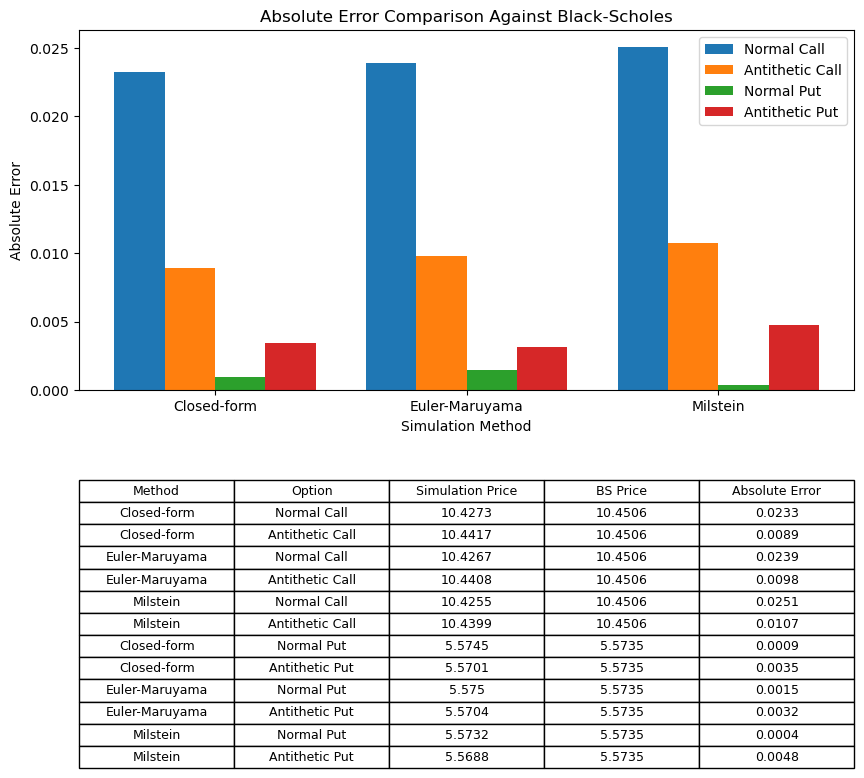

In [10]:
methods = [
    "Closed-form",
    "Euler-Maruyama",
    "Milstein"
]

normal_call_error = [
    abs(call_price_closed - black_scholes_call),
    abs(call_price_EM - black_scholes_call),
    abs(call_price_milstein - black_scholes_call)
]

antithetic_call_error = [
    abs(closed_call_price_antithetic - black_scholes_call),
    abs(em_call_price_antithetic - black_scholes_call),
    abs(milstein_call_price_antithetic - black_scholes_call)
]

normal_put_error = [
    abs(put_price_closed - black_scholes_put),
    abs(put_price_EM - black_scholes_put),
    abs(put_price_milstein - black_scholes_put)
]

antithetic_put_error = [
    abs(closed_put_price_antithetic - black_scholes_put),
    abs(em_put_price_antithetic - black_scholes_put),
    abs(milstein_put_price_antithetic - black_scholes_put)
]

x = np.arange(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize = (10, 10))

ax.bar(
    x - 1.5 * width,
    normal_call_error,
    width,
    label = "Normal Call"
)

ax.bar(
    x - 0.5 * width,
    antithetic_call_error,
    width,
    label = "Antithetic Call"
)

ax.bar(
    x + 0.5 * width,
    normal_put_error,
    width,
    label = "Normal Put"
)

ax.bar(
    x + 1.5 * width,
    antithetic_put_error,
    width,
    label = "Antithetic Put"
)

ax.set_xticks(x)
ax.set_xticklabels(methods)

ax.set_xlabel("Simulation Method")
ax.set_ylabel("Absolute Error")
ax.set_title("Absolute Error Comparison Against Black-Scholes")

ax.legend()




table_data = [
    [
        "Closed-form",
        "Normal Call",
        round(call_price_closed, 4),
        round(black_scholes_call, 4),
        round(abs(call_price_closed - black_scholes_call), 4)
    ],

    [
        "Closed-form",
        "Antithetic Call",
        round(closed_call_price_antithetic, 4),
        round(black_scholes_call, 4),
        round(abs(closed_call_price_antithetic - black_scholes_call), 4)
    ],

    [
        "Euler-Maruyama",
        "Normal Call",
        round(call_price_EM, 4),
        round(black_scholes_call, 4),
        round(abs(call_price_EM - black_scholes_call), 4)
    ],

    [
        "Euler-Maruyama",
        "Antithetic Call",
        round(em_call_price_antithetic, 4),
        round(black_scholes_call, 4),
        round(abs(em_call_price_antithetic - black_scholes_call), 4)
    ],

    [
        "Milstein",
        "Normal Call",
        round(call_price_milstein, 4),
        round(black_scholes_call, 4),
        round(abs(call_price_milstein - black_scholes_call), 4)
    ],

    [
        "Milstein",
        "Antithetic Call",
        round(milstein_call_price_antithetic, 4),
        round(black_scholes_call, 4),
        round(abs(milstein_call_price_antithetic - black_scholes_call), 4)
    ],

    [
        "Closed-form",
        "Normal Put",
        round(put_price_closed, 4),
        round(black_scholes_put, 4),
        round(abs(put_price_closed - black_scholes_put), 4)
    ],

    [
        "Closed-form",
        "Antithetic Put",
        round(closed_put_price_antithetic, 4),
        round(black_scholes_put, 4),
        round(abs(closed_put_price_antithetic - black_scholes_put), 4)
    ],

    [
        "Euler-Maruyama",
        "Normal Put",
        round(put_price_EM, 4),
        round(black_scholes_put, 4),
        round(abs(put_price_EM - black_scholes_put), 4)
    ],

    [
        "Euler-Maruyama",
        "Antithetic Put",
        round(em_put_price_antithetic, 4),
        round(black_scholes_put, 4),
        round(abs(em_put_price_antithetic - black_scholes_put), 4)
    ],

    [
        "Milstein",
        "Normal Put",
        round(put_price_milstein, 4),
        round(black_scholes_put, 4),
        round(abs(put_price_milstein - black_scholes_put), 4)
    ],

    [
        "Milstein",
        "Antithetic Put",
        round(milstein_put_price_antithetic, 4),
        round(black_scholes_put, 4),
        round(abs(milstein_put_price_antithetic - black_scholes_put), 4)
    ]
]


column_labels = [
    "Method",
    "Option",
    "Simulation Price",
    "BS Price",
    "Absolute Error"
]

table = ax.table(
    cellText = table_data,
    colLabels = column_labels,
    cellLoc = "center",
    colLoc = "center",
    loc = "bottom",
    bbox = [0, -1.05, 1, 0.80]
)

table.auto_set_font_size(False)
table.set_fontsize(9)

plt.subplots_adjust(
    bottom = 0.52
)

plt.show()

The baseline Monte Carlo estimates are compared with the analytical Black-Scholes prices in order to evaluate the pricing accuracy of the closed-form, Euler-Maruyama and Milstein simulation methods (Glasserman, 2004).

For each numerical estimate, the absolute pricing error is calculated as

$$
\text{Absolute Error}
=
\left|
\hat V_{\text{MC}}
-
V_{\text{BS}}
\right|,
$$

where $\hat V_{\text{MC}}$ denotes the Monte Carlo estimate and $V_{\text{BS}}$ denotes the corresponding analytical Black-Scholes value. Under the baseline parameters,

$$
S_0=100,\qquad
K=100,\qquad
r=5\%,\qquad
\sigma=20\%,\qquad
T=1,
$$

the Black-Scholes benchmark prices are

$$
C_{BS}=10.4506
$$

and

$$
P_{BS}=5.5735.
$$

Overall, all three Monte Carlo methods produce prices close to the corresponding analytical benchmarks.

---

### Call Option Results

For the ordinary Monte Carlo simulations, the estimated call prices are

$$
10.4273,\qquad
10.4267,\qquad
10.4255
$$

for the closed-form, Euler-Maruyama and Milstein methods, respectively.The corresponding absolute errors are

$$
0.0233,\qquad
0.0239,\qquad
0.0251.
$$

All three estimates slightly underestimate the Black-Scholes call value.The differences between the three methods are small. Although Milstein has the largest realised error in this particular simulation, this should not be interpreted as evidence that Milstein is generally less accurate than Euler-Maruyama.

The closed-form method uses the exact GBM transition and therefore does not introduce SDE time-discretisation bias. Euler-Maruyama and Milstein, by contrast, approximate the continuous stock-price process using a finite time grid.

However, with 252 time steps per year, the remaining discretisation differences are relatively small compared with the Monte Carlo sampling variation observed in this experiment.

After applying antithetic variates, the corresponding call estimates become

$$
10.4417,\qquad
10.4408,\qquad
10.4399,
$$

with absolute errors

$$
0.0089,\qquad
0.0098,\qquad
0.0107.
$$

Therefore, the realised call pricing errors are smaller under the antithetic implementation for all three simulation schemes. For example, the closed-form call error decreases from

$$
0.0233
$$

to

$$
0.0089.
$$

This result is consistent with the purpose of antithetic sampling, although absolute error alone is not sufficient to evaluate variance-reduction performance.

---

### Put Option Results

For the ordinary Monte Carlo put simulations, the estimated prices are

$$
5.5745,\qquad
5.5750,\qquad
5.5732
$$

for the closed-form, Euler-Maruyama and Milstein methods.The corresponding absolute errors are

$$
0.0009,\qquad
0.0015,\qquad
0.0004.
$$

All three estimates are extremely close to the Black-Scholes put value of

$$
5.5735.
$$

In this particular simulation, the Milstein estimate happens to have the smallest realised put error. However, this ranking is sample-specific and does not imply that Milstein is theoretically more exact than the closed-form GBM transition. After applying antithetic variates, the put estimates become

$$
5.5701,\qquad
5.5704,\qquad
5.5688,
$$

with absolute errors

$$
0.0035,\qquad
0.0032,\qquad
0.0048.
$$

Unlike the call results, the antithetic put estimates are slightly further from the Black-Scholes benchmark in this particular simulation. This does not imply that antithetic sampling has failed. Absolute pricing error measures the distance between one realised estimate and the benchmark,

$$
\left|
\hat V_{\text{MC}}
-
V_{\text{BS}}
\right|,
$$

whereas estimator variance measures the variability of the Monte Carlo estimator across repeated samples.

Therefore,

$$
\text{smaller estimator variance}
\not\Rightarrow
\text{smaller absolute error in every simulation}.
$$

The effectiveness of antithetic variates is therefore examined more formally using estimator variance and standard error in the following section.

---

### Comparison of the Simulation Methods

The baseline results illustrate the distinction between sampling error and discretisation error. For the closed-form GBM method,

$$
S_{t+\Delta t}
=
S_t
\exp
\left[
\left(
r-\frac{1}{2}\sigma^2
\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right]
$$

is the exact GBM transition under the assumed constant parameters.

Therefore,

$$
\text{Closed-form Monte Carlo}
\rightarrow
\text{sampling error}.
$$

Euler-Maruyama and Milstein instead approximate the SDE using finite time steps, so their numerical estimates can be affected by both

$$
\text{sampling error}
$$

and

$$
\text{discretisation error}.
$$

The relatively small differences between the three pricing methods suggest that, at 252 time steps per year, the remaining discretisation effects are small relative to the Monte Carlo sampling uncertainty in the present experiment.

A more direct investigation of discretisation accuracy would require varying the number of time steps while controlling the random numbers used across the numerical schemes.

---

### Main Findings

The baseline pricing results show that all three Monte Carlo implementations reproduce the Black-Scholes call and put prices closely.

For the call option, antithetic sampling produces smaller realised absolute errors than ordinary Monte Carlo in this simulation.

For the put option, the ordinary Monte Carlo estimates happen to lie extremely close to the analytical benchmark, while the antithetic estimates have slightly larger realised errors.

This difference highlights an important statistical distinction: absolute pricing error from one simulation is not the same as estimator precision.

The next analysis therefore compares estimator variance and standard error in order to determine whether antithetic variates improve the statistical efficiency of the Monte Carlo estimator.

## 2.b Estimator Variance and Standard Error Analysis


In [11]:
variance_se_table = pd.DataFrame({

    "Method": [
        "Closed-form",
        "Closed-form",
        "Euler-Maruyama",
        "Euler-Maruyama",
        "Milstein",
        "Milstein",
        "Closed-form",
        "Closed-form",
        "Euler-Maruyama",
        "Euler-Maruyama",
        "Milstein",
        "Milstein"
    ],

    "Sampling": [
        "Normal",
        "Normal",
        "Normal",
        "Normal",
        "Normal",
        "Normal",
        "Antithetic",
        "Antithetic",
        "Antithetic",
        "Antithetic",
        "Antithetic",
        "Antithetic"
    ],

    "Option Type": [
        "Call",
        "Put",
        "Call",
        "Put",
        "Call",
        "Put",
        "Call",
        "Put",
        "Call",
        "Put",
        "Call",
        "Put"
    ],

    "Estimator Variance": [
        call_var_closed,
        put_var_closed,
        call_var_EM,
        put_var_EM,
        call_var_milstein,
        put_var_milstein,
        closed_call_variance_antithetic,
        closed_put_variance_antithetic,
        em_call_variance_antithetic,
        em_put_variance_antithetic,
        milstein_call_variance_antithetic,
        milstein_put_variance_antithetic
    ],

    "Standard Error": [
        call_se_closed,
        put_se_closed,
        call_se_EM,
        put_se_EM,
        call_se_milstein,
        put_se_milstein,
        closed_call_se_antithetic,
        closed_put_se_antithetic,
        em_call_se_antithetic,
        em_put_se_antithetic,
        milstein_call_se_antithetic,
        milstein_put_se_antithetic
    ]
})

variance_se_table.round(6)

,Method,Sampling,Option Type,Estimator Variance,Standard Error
0,Closed-form,Normal,Call,0.002147,0.046337
1,Closed-form,Normal,Put,0.000750,0.027394
2,Euler-Maruyama,Normal,Call,0.002144,0.046308
3,Euler-Maruyama,Normal,Put,0.000751,0.027406
4,Milstein,Normal,Call,0.002146,0.046327
5,Milstein,Normal,Put,0.000750,0.027389
6,Closed-form,Antithetic,Call,0.000537,0.023170
7,Closed-form,Antithetic,Put,0.000219,0.014788
8,Euler-Maruyama,Antithetic,Call,0.000536,0.023144
9,Euler-Maruyama,Antithetic,Put,0.000219,0.014798


Absolute pricing error measures how close one realised Monte Carlo estimate is to the analytical Black-Scholes benchmark. However, it does not directly measure the statistical precision of the estimator.

Let $X_i$ denote the discounted payoff from simulation $i$. The Monte Carlo estimator is

$$
\hat V
=
\frac{1}{N}
\sum_{i=1}^{N}X_i.
$$

If

$$
\operatorname{Var}(X_i)
=
\sigma_X^2,
$$

then

$$
\operatorname{Var}(\hat V)
=
\frac{\sigma_X^2}{N},
$$

and the corresponding standard error is

$$
SE(\hat V)
=
\frac{\sigma_X}{\sqrt N}.
$$

A smaller estimator variance and standard error therefore indicate a more statistically stable Monte Carlo estimator.

---

### Standard Monte Carlo Results

For the call option, the estimator variances under the closed-form, Euler-Maruyama and Milstein methods are

$$
0.002147,\qquad
0.002144,\qquad
0.002146,
$$

with corresponding standard errors

$$
0.046337,\qquad
0.046308,\qquad
0.046327.
$$

For the put option, the estimator variances are

$$
0.000750,\qquad
0.000751,\qquad
0.000750,
$$

with standard errors

$$
0.027394,\qquad
0.027406,\qquad
0.027389.
$$

The results are almost identical across the three simulation methods.

This suggests that, under the baseline setting of 252 time steps, the differences in sampling variability between the closed-form, Euler-Maruyama and Milstein implementations are very small.

The call estimators also exhibit higher variance than the put estimators under the current parameter setting. For example,

$$
\operatorname{Var}(\hat C)
=
0.002147
$$

for the closed-form call, compared with

$$
\operatorname{Var}(\hat P)
=
0.000750
$$

for the corresponding put.

This result is specific to the current payoff distributions and parameter setting and should not be interpreted as a general rule that call options always have higher Monte Carlo variance.

---

### Effect of Antithetic Variates

Antithetic sampling produces a substantial reduction in estimator variance and standard error.

For the call option, the estimator variances decrease approximately as follows:

$$
0.002147
\rightarrow
0.000537
$$

for the closed-form method,

$$
0.002144
\rightarrow
0.000536
$$

for Euler-Maruyama, and

$$
0.002146
\rightarrow
0.000537
$$

for Milstein.

The corresponding standard errors decrease from approximately

$$
0.0463
$$

to

$$
0.0232.
$$

The variance reduction ratio is defined as

$$
\text{VRR}
=
\frac{
\operatorname{Var}(\hat V_{\text{Normal}})
}{
\operatorname{Var}(\hat V_{\text{Antithetic}})
}.
$$

For the call estimators,

$$
\text{VRR}
\approx
4,
$$

corresponding to an approximate variance reduction of

$$
75\%.
$$

The standard error is reduced by approximately

$$
50\%.
$$

A similar pattern is observed for the put option. The estimator variance decreases from approximately

$$
0.000750
$$

to

$$
0.000219,
$$

while the standard error decreases from approximately

$$
0.0274
$$

to

$$
0.0148.
$$

The corresponding variance reduction ratio is approximately

$$
3.4,
$$

which represents a variance reduction of about

$$
71\%.
$$

These results show that the antithetic procedure substantially reduces the sampling variability of both call and put estimators in the current implementation.

---

### Relation to the Absolute Error Results

The variance results also explain an important feature of the previous pricing-error analysis.

For the call option, antithetic sampling reduced both the realised absolute pricing error and the estimator variance.

For the put option, however, the antithetic estimates had slightly larger realised absolute errors even though their estimator variances and standard errors were substantially lower.

This confirms that

$$
\text{Absolute Error}
\neq
\text{Estimator Variance}.
$$

A Monte Carlo estimator can have lower variance while still producing a larger error in one particular simulation.

Therefore, the performance of a variance-reduction method should be evaluated using estimator variance and standard error rather than relying only on one realised pricing error.

---

### Comparison Across Simulation Methods

The antithetic variance-reduction effect is highly consistent across the closed-form, Euler-Maruyama and Milstein methods.

For the call option, all three antithetic estimator variances are approximately

$$
0.000536
\text{ to }
0.000537,
$$

while for the put option they are approximately

$$
0.000219.
$$

This indicates that the reduction in sampling variability is primarily generated by the antithetic sampling procedure rather than by the stock-price discretisation method.

The numerical roles of the two techniques are therefore different:

$$
\text{Milstein}
\rightarrow
\text{improves SDE discretisation},
$$

whereas

$$
\text{Antithetic Variates}
\rightarrow
\text{reduce Monte Carlo sampling variance}.
$$

---

### Main Finding

The estimator variance and standard error results provide stronger evidence of the effectiveness of antithetic variates than the absolute-error comparison alone.

Under the present implementation, antithetic sampling reduces call estimator variance by approximately 75% and put estimator variance by approximately 71%, with substantial reductions in standard error.

The results also confirm that variance reduction and discretisation improvement address different numerical problems, and that a single realised pricing error should not be used as the sole measure of Monte Carlo efficiency.

---
### Computational-Budget Consideration

It should be noted that the antithetic implementation uses 100,000 paired observations. Each pair contains two simulated paths generated from $Z$ and $-Z$, so this corresponds to 200,000 raw simulated paths.The standard Monte Carlo implementation, by comparison, uses 100,000 raw paths.

Therefore, the reported reduction in estimator variance demonstrates the statistical effectiveness of the implemented antithetic estimator, but it should not be interpreted as a strict equal-computational-budget comparison.A fully equal-path comparison would, for example, compare 100,000 ordinary Monte Carlo paths with 50,000 antithetic pairs.

---
## 2.c Delta Analysis


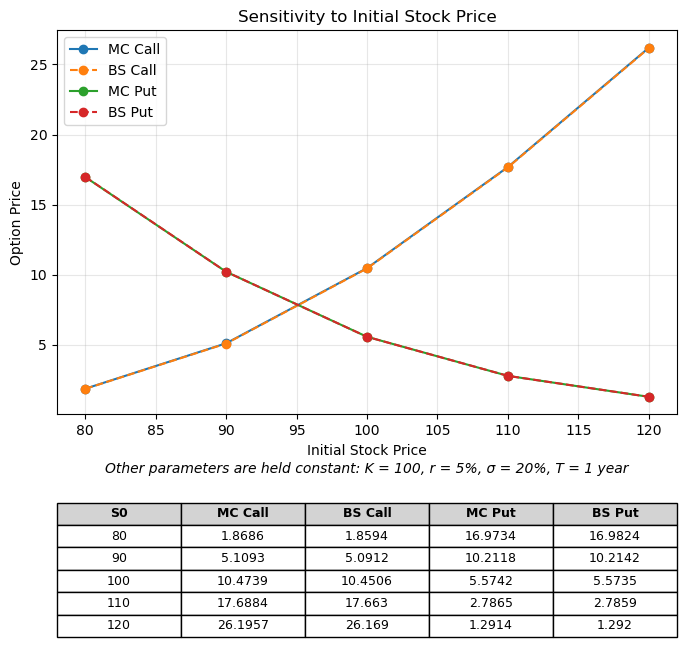

,S0,MC Call Delta,BS Call Delta,MC Put Delta,BS Put Delta
0,80,0.2220,0.2219,-0.7773,-0.7781
1,90,0.4275,0.4298,-0.5718,-0.5702
2,100,0.6346,0.6368,-0.3648,-0.3632
3,110,0.7940,0.7958,-0.2054,-0.2042
4,120,0.8950,0.8965,-0.1043,-0.1035


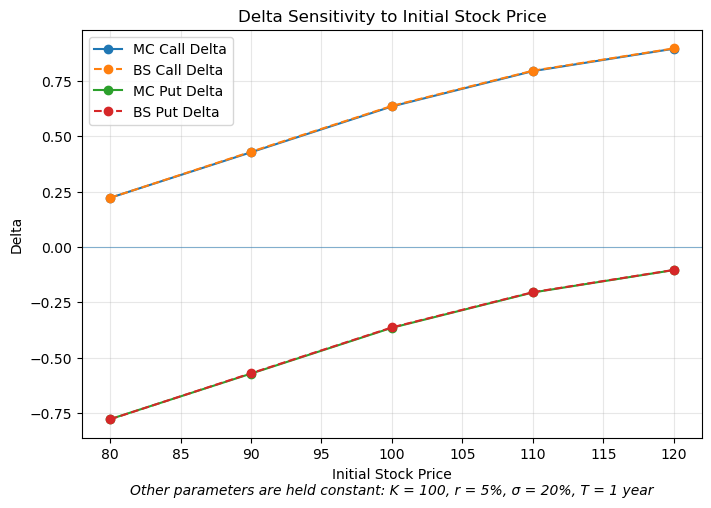

In [12]:
S0_values = [
    80, 90, 100, 110, 120
]

mc_call_S0 = []
mc_put_S0 = []

bs_call_S0 = []
bs_put_S0 = []


for S0 in S0_values:

    call_price, put_price, _, _, _, _ = big_jump_closed_stats(
        S0, 100, 0.05, 0.2, 1, 100000
    )

    bs_call, bs_put = black_scholes(
        S0, 100, 0.05, 1, 0.2
    )

    mc_call_S0.append(
        call_price
    )

    mc_put_S0.append(
        put_price
    )

    bs_call_S0.append(
        bs_call
    )

    bs_put_S0.append(
        bs_put
    )


S0_sensitivity_table = pd.DataFrame({

    "S0": S0_values,

    "MC Call": mc_call_S0,

    "BS Call": bs_call_S0,

    "MC Put": mc_put_S0,

    "BS Put": bs_put_S0
})


fig, ax = plt.subplots(
    figsize = (8, 8)
)


ax.plot(
    S0_values,
    mc_call_S0,
    marker = "o",
    label = "MC Call"
)

ax.plot(
    S0_values,
    bs_call_S0,
    marker = "o",
    linestyle = "--",
    label = "BS Call"
)

ax.plot(
    S0_values,
    mc_put_S0,
    marker = "o",
    label = "MC Put"
)

ax.plot(
    S0_values,
    bs_put_S0,
    marker = "o",
    linestyle = "--",
    label = "BS Put"
)


ax.set_xlabel(
    "Initial Stock Price"
)

ax.set_ylabel(
    "Option Price"
)

ax.set_title(
    "Sensitivity to Initial Stock Price"
)

ax.legend()

ax.grid(
    alpha = 0.3
)


# Note for fixed parameters
ax.text(
    0.5,
    -0.12,
    "\nOther parameters are held constant: K = 100, r = 5%, σ = 20%, T = 1 year",
    transform = ax.transAxes,
    ha = "center",
    va = "center",
    fontsize = 10,
    style = "italic"
)


table_data = [
    [
        round(S0_values[i], 4),
        round(mc_call_S0[i], 4),
        round(bs_call_S0[i], 4),
        round(mc_put_S0[i], 4),
        round(bs_put_S0[i], 4)
    ]

    for i in range(
        len(S0_values)
    )
]


column_labels = [
    "S0",
    "MC Call",
    "BS Call",
    "MC Put",
    "BS Put"
]


table = ax.table(
    cellText = table_data,
    colLabels = column_labels,
    cellLoc = "center",
    colLoc = "center",
    loc = "bottom",
    bbox = [0, -0.58, 1, 0.35]
)


# Change header color
for j in range(
    len(column_labels)
):

    table[(0, j)].set_facecolor(
        "lightgray"
    )

    table[(0, j)].set_text_props(
        weight = "bold"
    )


table.auto_set_font_size(
    False
)

table.set_fontsize(
    9
)


plt.subplots_adjust(
    bottom = 0.4
)

plt.show()


# ============================================================
# Delta Analysis
# ============================================================

from scipy.stats import norm


# Parameters
K = 100
r = 0.05
sigma = 0.20
T = 1
n_paths = 100000
seed = 42

# Central-difference bump
h = 1.0


# ------------------------------------------------------------
# Black-Scholes Delta
# ------------------------------------------------------------

def black_scholes_delta(S0, K, r, T, sigma):

    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * sigma ** 2) * T
    ) / (
        sigma * np.sqrt(T)
    )

    call_delta = norm.cdf(d1)
    put_delta = norm.cdf(d1) - 1

    return call_delta, put_delta


# ------------------------------------------------------------
# Big-jump Monte Carlo price
# Uses supplied random numbers
# ------------------------------------------------------------

def mc_big_jump_price(S0, K, r, sigma, T, z):

    ST = S0 * np.exp(
        (r - 0.5 * sigma ** 2) * T
        + sigma * np.sqrt(T) * z
    )

    call_payoff = np.maximum(
        ST - K,
        0
    )

    put_payoff = np.maximum(
        K - ST,
        0
    )

    discount_factor = np.exp(
        -r * T
    )

    call_price = (
        discount_factor
        * np.mean(call_payoff)
    )

    put_price = (
        discount_factor
        * np.mean(put_payoff)
    )

    return call_price, put_price


# ------------------------------------------------------------
# Generate one common set of random numbers
# ------------------------------------------------------------

rng = np.random.default_rng(seed)

z = rng.standard_normal(
    n_paths
)


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

mc_call_delta = []
mc_put_delta = []

bs_call_delta = []
bs_put_delta = []


# ------------------------------------------------------------
# Calculate Delta at each S0
# ------------------------------------------------------------

for S0 in S0_values:

    # Monte Carlo price when stock moves up
    call_up, put_up = mc_big_jump_price(
        S0 + h,
        K,
        r,
        sigma,
        T,
        z
    )

    # Monte Carlo price when stock moves down
    call_down, put_down = mc_big_jump_price(
        S0 - h,
        K,
        r,
        sigma,
        T,
        z
    )

    # Central-difference Monte Carlo Delta
    call_delta_mc = (
        call_up - call_down
    ) / (
        2 * h
    )

    put_delta_mc = (
        put_up - put_down
    ) / (
        2 * h
    )

    mc_call_delta.append(
        call_delta_mc
    )

    mc_put_delta.append(
        put_delta_mc
    )


    # Analytical Black-Scholes Delta
    call_delta_bs, put_delta_bs = black_scholes_delta(
        S0,
        K,
        r,
        T,
        sigma
    )

    bs_call_delta.append(
        call_delta_bs
    )

    bs_put_delta.append(
        put_delta_bs
    )


# ------------------------------------------------------------
# Delta Table
# ------------------------------------------------------------

delta_table = pd.DataFrame({

    "S0": S0_values,

    "MC Call Delta": mc_call_delta,

    "BS Call Delta": bs_call_delta,

    "MC Put Delta": mc_put_delta,

    "BS Put Delta": bs_put_delta

})


display(
    delta_table.round(4)
)


# ------------------------------------------------------------
# Delta Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize = (8, 6)
)


ax.plot(
    S0_values,
    mc_call_delta,
    marker = "o",
    label = "MC Call Delta"
)

ax.plot(
    S0_values,
    bs_call_delta,
    marker = "o",
    linestyle = "--",
    label = "BS Call Delta"
)

ax.plot(
    S0_values,
    mc_put_delta,
    marker = "o",
    label = "MC Put Delta"
)

ax.plot(
    S0_values,
    bs_put_delta,
    marker = "o",
    linestyle = "--",
    label = "BS Put Delta"
)


ax.axhline(
    y = 0,
    linewidth = 0.8,
    alpha = 0.5
)


ax.set_xlabel(
    "Initial Stock Price"
)

ax.set_ylabel(
    "Delta"
)

ax.set_title(
    "Delta Sensitivity to Initial Stock Price"
)

ax.legend()

ax.grid(
    alpha = 0.3
)


ax.text(
    0.5,
    -0.14,
    "Other parameters are held constant: "
    "K = 100, r = 5%, σ = 20%, T = 1 year",
    transform = ax.transAxes,
    ha = "center",
    fontsize = 10,
    style = "italic"
)


plt.subplots_adjust(
    bottom = 0.2
)

plt.show()

Delta measures the sensitivity of the option value to changes in the underlying stock price:

$$
\Delta
=
\frac{\partial V}{\partial S}.
$$

In the Monte Carlo simulation, Delta is estimated using a central finite-difference approximation:

$$
\Delta_{MC}
\approx
\frac{
V(S_0+h)-V(S_0-h)
}{
2h
}.
$$

In this experiment,

$$
h=1,
$$

and the same random numbers are used for the upward and downward stock-price scenarios in order to reduce Monte Carlo noise.

The Monte Carlo Delta estimates are compared with the corresponding analytical Black-Scholes values.

### Call and Put Delta

The call-option Delta is positive across all tested stock prices, while the put-option Delta is negative.

For the call option, the Monte Carlo Delta increases from

$$
0.2220
$$

at

$$
S_0=80
$$

to

$$
0.8950
$$

at

$$
S_0=120.
$$

The corresponding Black-Scholes values increase from

$$
0.2219
$$

to

$$
0.8965.
$$

Therefore,

$$
\Delta_{\text{Call}}>0.
$$

As the stock price increases, the call becomes more sensitive to movements in the underlying asset and its Delta approaches one.

For the put option, the Monte Carlo Delta changes from

$$
-0.7773
$$

at

$$
S_0=80
$$

to

$$
-0.1043
$$

at

$$
S_0=120.
$$

The corresponding Black-Scholes values change from

$$
-0.7781
$$

to

$$
-0.1035.
$$

Therefore,

$$
\Delta_{\text{Put}}<0.
$$

As the stock price increases, the put becomes further out of the money and the magnitude of Delta decreases towards zero.

### Behaviour around the Strike Price

The strike price is

$$
K=100.
$$

At

$$
S_0=100,
$$

the Monte Carlo call Delta is

$$
0.6346,
$$

compared with the Black-Scholes value

$$
0.6368.
$$

The Monte Carlo put Delta is

$$
-0.3648,
$$

compared with the Black-Scholes value

$$
-0.3632.
$$

The close agreement indicates that the finite-difference Monte Carlo procedure reproduces the analytical Delta accurately.

The call Delta is not exactly $0.5$ at $S_0=K$ because Delta depends not only on the relationship between stock price and strike price, but also on volatility, time to maturity and the risk-free interest rate.

### Monte Carlo versus Black-Scholes

Across the entire stock-price range, the Monte Carlo Delta estimates remain very close to the analytical Black-Scholes values.

At

$$
S_0=100,
$$

the absolute difference for the call Delta is approximately

$$
|0.6346-0.6368|
=
0.0022,
$$

while for the put option it is approximately

$$
|-0.3648-(-0.3632)|
=
0.0016.
$$

This close agreement supports the accuracy of the numerical finite-difference Delta estimation.

An additional consistency check is provided by the call-put Delta relationship for a non-dividend-paying stock:

$$
\Delta_{\text{Call}}
-
\Delta_{\text{Put}}
=
1.
$$

At

$$
S_0=100,
$$

the Monte Carlo results give

$$
0.6346-(-0.3648)
=
0.9994,
$$

which is very close to the theoretical value of one.

### Interpretation

The Delta results show the expected first-order sensitivity of European call and put options to movements in the underlying stock price.

As $S_0$ increases,

$$
\Delta_{\text{Call}}
\rightarrow 1,
$$

while

$$
\Delta_{\text{Put}}
\rightarrow 0.
$$

At lower stock prices,

$$
\Delta_{\text{Call}}
\rightarrow 0,
$$

while

$$
\Delta_{\text{Put}}
\rightarrow -1.
$$

The fact that Delta changes as the stock price changes indicates that the option-price relationship is nonlinear. This leads naturally to Gamma, which measures the rate of change of Delta:

$$
\Gamma
=
\frac{\partial \Delta}{\partial S}
=
\frac{\partial^2V}{\partial S^2}.
$$

---

## 2.d Gamma Analysis


,S0,MC Call Gamma,BS Call Gamma,MC Put Gamma,BS Put Gamma
0,80,0.018765,0.018598,0.018765,0.018598
1,90,0.022054,0.021820,0.022054,0.021820
2,100,0.018647,0.018762,0.018647,0.018762
3,110,0.012936,0.012887,0.012936,0.012887
4,120,0.007413,0.007500,0.007413,0.007500


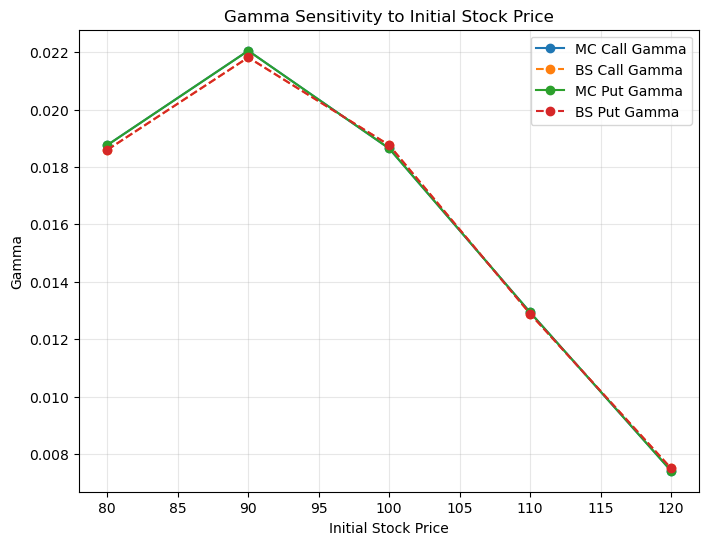

In [13]:
S0_values = [
    80, 90, 100, 110, 120
]

K = 100
r = 0.05
sigma = 0.20
T = 1
n_paths = 100000
seed = 42

h_S = 1.0


def black_scholes_gamma(
    S0,
    K,
    r,
    T,
    sigma
):

    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * sigma ** 2) * T
    ) / (
        sigma * np.sqrt(T)
    )

    gamma = (
        norm.pdf(d1)
        / (
            S0
            * sigma
            * np.sqrt(T)
        )
    )

    return gamma


rng = np.random.default_rng(
    seed
)

z_gamma = rng.standard_normal(
    n_paths
)


mc_call_gamma = []
mc_put_gamma = []

bs_call_gamma = []
bs_put_gamma = []


for S0 in S0_values:

    call_up, put_up = mc_big_jump_price(
        S0 + h_S,
        K,
        r,
        sigma,
        T,
        z_gamma
    )

    call_mid, put_mid = mc_big_jump_price(
        S0,
        K,
        r,
        sigma,
        T,
        z_gamma
    )

    call_down, put_down = mc_big_jump_price(
        S0 - h_S,
        K,
        r,
        sigma,
        T,
        z_gamma
    )


    call_gamma_mc = (
        call_up
        - 2 * call_mid
        + call_down
    ) / (
        h_S ** 2
    )


    put_gamma_mc = (
        put_up
        - 2 * put_mid
        + put_down
    ) / (
        h_S ** 2
    )


    mc_call_gamma.append(
        call_gamma_mc
    )

    mc_put_gamma.append(
        put_gamma_mc
    )


    gamma_bs = black_scholes_gamma(
        S0,
        K,
        r,
        T,
        sigma
    )


    bs_call_gamma.append(
        gamma_bs
    )

    bs_put_gamma.append(
        gamma_bs
    )


gamma_table = pd.DataFrame({

    "S0": S0_values,

    "MC Call Gamma": mc_call_gamma,

    "BS Call Gamma": bs_call_gamma,

    "MC Put Gamma": mc_put_gamma,

    "BS Put Gamma": bs_put_gamma

})


display(
    gamma_table.round(6)
)


fig, ax = plt.subplots(
    figsize = (8, 6)
)


ax.plot(
    S0_values,
    mc_call_gamma,
    marker = "o",
    label = "MC Call Gamma"
)

ax.plot(
    S0_values,
    bs_call_gamma,
    marker = "o",
    linestyle = "--",
    label = "BS Call Gamma"
)

ax.plot(
    S0_values,
    mc_put_gamma,
    marker = "o",
    label = "MC Put Gamma"
)

ax.plot(
    S0_values,
    bs_put_gamma,
    marker = "o",
    linestyle = "--",
    label = "BS Put Gamma"
)


ax.set_xlabel(
    "Initial Stock Price"
)

ax.set_ylabel(
    "Gamma"
)

ax.set_title(
    "Gamma Sensitivity to Initial Stock Price"
)

ax.legend()

ax.grid(
    alpha = 0.3
)

plt.show()

Gamma measures the rate of change of Delta with respect to the underlying stock price:

$$
\Gamma
=
\frac{\partial \Delta}{\partial S}
=
\frac{\partial^2V}{\partial S^2}.
$$

While Delta measures first-order sensitivity, Gamma measures the curvature of the option-price function.

In the Monte Carlo analysis, Gamma is estimated using the central second-difference approximation:

$$
\Gamma_{MC}
\approx
\frac{
V(S_0+h)-2V(S_0)+V(S_0-h)
}{
h^2
}.
$$

In this experiment,

$$
h=1.
$$

The same random numbers are used for the upward, central and downward stock-price scenarios in order to reduce Monte Carlo noise.

The Monte Carlo estimates are compared with the analytical Black-Scholes Gamma:

$$
\Gamma_{BS}
=
\frac{
\phi(d_1)
}{
S_0\sigma\sqrt T
}.
$$

### Gamma across Stock Prices

Gamma is positive for both the call and put options across all tested stock-price levels.

The Monte Carlo Gamma increases from

$$
0.018765
$$

at

$$
S_0=80
$$

to approximately

$$
0.022054
$$

at

$$
S_0=90,
$$

before decreasing to

$$
0.007413
$$

at

$$
S_0=120.
$$

The Black-Scholes Gamma follows almost the same pattern.

This reflects the fact that Gamma is largest in the region where Delta changes most rapidly. When an option becomes far in or out of the money, Delta changes more slowly and Gamma decreases.

### Location of the Gamma Peak

The strike price is

$$
K=100,
$$

while the largest observed Gamma occurs near

$$
S_0=90.
$$

Gamma does not necessarily attain its maximum exactly at

$$
S_0=K.
$$

Under Black-Scholes,

$$
\Gamma
=
\frac{\phi(d_1)}
{S_0\sigma\sqrt T},
$$

so the location of the maximum depends not only on the normal-density term $\phi(d_1)$ but also on the factor $1/S_0$.

For the current parameters,

$$
K=100,\qquad
r=5\%,\qquad
\sigma=20\%,\qquad
T=1,
$$

the theoretical Gamma maximum occurs slightly below the strike. Therefore, the observed peak around

$$
S_0=90
$$

is consistent with the analytical Black-Scholes Gamma curve.

### Monte Carlo versus Black-Scholes Gamma

The Monte Carlo estimates remain very close to the analytical values across the tested stock-price range.

At

$$
S_0=100,
$$

the Monte Carlo Gamma is

$$
0.018647,
$$

while the Black-Scholes value is

$$
0.018762.
$$

The absolute difference is only

$$
0.000115.
$$

Similarly, at

$$
S_0=110,
$$

the Monte Carlo Gamma is

$$
0.012936,
$$

compared with the Black-Scholes value

$$
0.012887.
$$

The close agreement indicates that the second-order finite-difference procedure successfully captures the curvature of the option-price function.

### Call and Put Gamma

European calls and puts with the same strike and maturity have identical Gamma under the Black-Scholes framework:

$$
\Gamma_{\text{Call}}
=
\Gamma_{\text{Put}}.
$$

This relationship is reproduced by the Monte Carlo results. At

$$
S_0=100,
$$

both the call and put Monte Carlo Gamma equal

$$
0.018647.
$$

This result is consistent with put-call parity:

$$
C-P
=
S_0-Ke^{-rT}.
$$

Taking the second derivative with respect to $S_0$ gives

$$
\frac{\partial^2C}{\partial S_0^2}
-
\frac{\partial^2P}{\partial S_0^2}
=
0,
$$

and therefore

$$
\Gamma_{\text{Call}}
=
\Gamma_{\text{Put}}.
$$

This provides an additional consistency check for the numerical Gamma calculation.

### Interpretation

A positive Gamma means that Delta increases as the stock price increases.

Gamma is largest in the region where Delta changes most rapidly and becomes smaller as the option moves further away from that region.

This is also important from a risk-management perspective. A position with high Gamma experiences faster changes in Delta when the stock price moves and therefore requires more frequent Delta-hedging adjustments.

Overall, the Monte Carlo second-order finite-difference estimates closely reproduce the analytical Black-Scholes Gamma values. Together with the Delta analysis, the results show that the Monte Carlo procedure captures both first-order and second-order sensitivity to movements in the underlying stock price.

---

## 2.e Theta Analysis


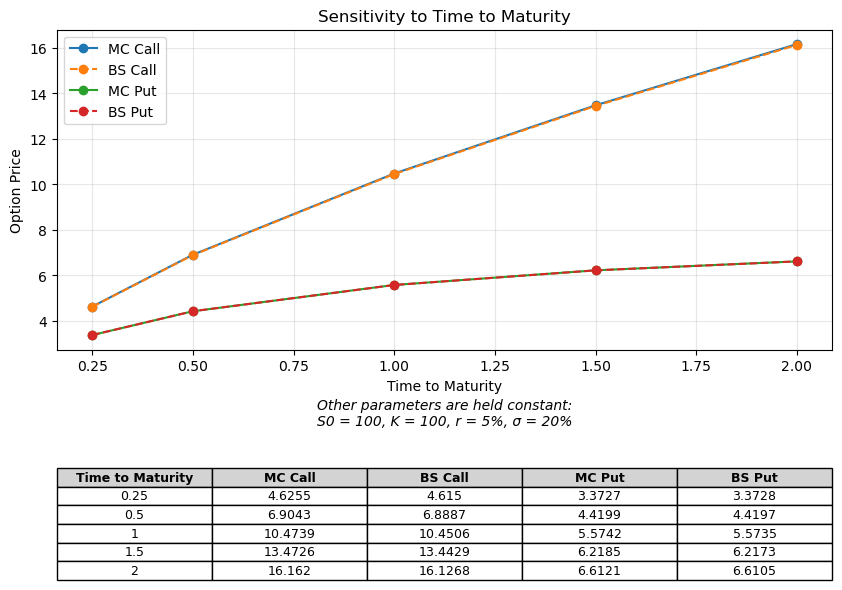

,Time to Maturity,MC Call Theta,BS Call Theta,MC Put Theta,BS Put Theta
0,0.25,-10.4434,-10.4742,-5.5745,-5.5363
1,0.50,-8.0944,-8.1160,-3.2617,-3.2394
2,1.00,-6.3996,-6.4140,-1.6692,-1.6579
3,1.50,-5.6183,-5.6288,-0.9971,-0.9901
4,2.00,-5.1299,-5.1378,-0.6182,-0.6136


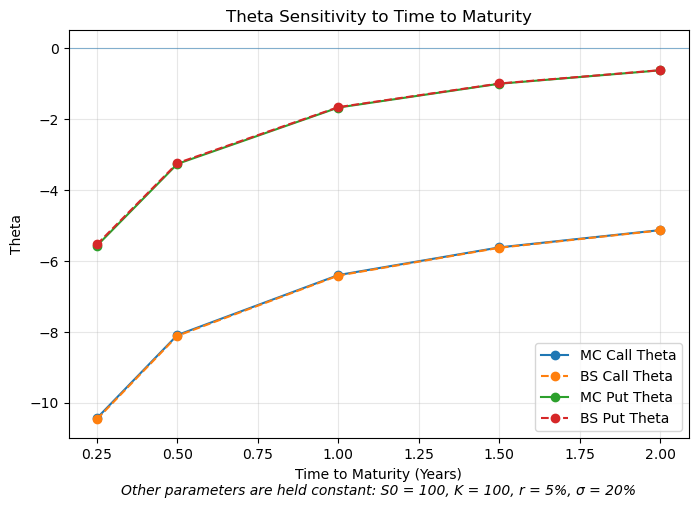

In [14]:
T_values = [
    0.25, 0.5, 1, 1.5, 2
]

mc_call_T = []
mc_put_T = []

bs_call_T = []
bs_put_T = []


for T in T_values:

    call_price, put_price, _, _, _, _ = big_jump_closed_stats(
        100, 100, 0.05, 0.2, T, 100000
    )

    bs_call, bs_put = black_scholes(
        100, 100, 0.05, T, 0.2
    )

    mc_call_T.append(
        call_price
    )

    mc_put_T.append(
        put_price
    )

    bs_call_T.append(
        bs_call
    )

    bs_put_T.append(
        bs_put
    )


T_sensitivity_table = pd.DataFrame({

    "Time to Maturity": T_values,

    "MC Call": mc_call_T,

    "BS Call": bs_call_T,

    "MC Put": mc_put_T,

    "BS Put": bs_put_T
})


fig, ax = plt.subplots(
    figsize = (10, 8)
)


ax.plot(
    T_values,
    mc_call_T,
    marker = "o",
    label = "MC Call"
)

ax.plot(
    T_values,
    bs_call_T,
    marker = "o",
    linestyle = "--",
    label = "BS Call"
)

ax.plot(
    T_values,
    mc_put_T,
    marker = "o",
    label = "MC Put"
)

ax.plot(
    T_values,
    bs_put_T,
    marker = "o",
    linestyle = "--",
    label = "BS Put"
)


ax.set_xlabel(
    "Time to Maturity"
)

ax.set_ylabel(
    "Option Price"
)

ax.set_title(
    "Sensitivity to Time to Maturity"
)

ax.legend()

ax.grid(
    alpha = 0.3
)


# Note for fixed parameters
ax.text(
    0.5,
    -0.20,
    "Other parameters are held constant:\n"
    "S0 = 100, K = 100, r = 5%, σ = 20%",
    transform = ax.transAxes,
    ha = "center",
    va = "center",
    fontsize = 10,
    style = "italic"
)


table_data = [
    [
        round(T_values[i], 4),
        round(mc_call_T[i], 4),
        round(bs_call_T[i], 4),
        round(mc_put_T[i], 4),
        round(bs_put_T[i], 4)
    ]

    for i in range(
        len(T_values)
    )
]


column_labels = [
    "Time to Maturity",
    "MC Call",
    "BS Call",
    "MC Put",
    "BS Put"
]


table = ax.table(
    cellText = table_data,
    colLabels = column_labels,
    cellLoc = "center",
    colLoc = "center",
    loc = "bottom",
    bbox = [0, -0.72, 1, 0.35]
)


# Change header color
for j in range(
    len(column_labels)
):

    table[(0, j)].set_facecolor(
        "lightgray"
    )

    table[(0, j)].set_text_props(
        weight = "bold"
    )


table.auto_set_font_size(
    False
)

table.set_fontsize(
    9
)


plt.subplots_adjust(
    bottom = 0.48
)

plt.show()

h_T = 1 / 252


# ------------------------------------------------------------
# Black-Scholes Analytical Theta
# ------------------------------------------------------------

def black_scholes_theta(
    S0,
    K,
    r,
    T,
    sigma
):

    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * sigma ** 2) * T
    ) / (
        sigma * np.sqrt(T)
    )

    d2 = (
        d1
        - sigma * np.sqrt(T)
    )


    call_theta = (
        -S0
        * norm.pdf(d1)
        * sigma
        / (2 * np.sqrt(T))
        - r
        * K
        * np.exp(-r * T)
        * norm.cdf(d2)
    )


    put_theta = (
        -S0
        * norm.pdf(d1)
        * sigma
        / (2 * np.sqrt(T))
        + r
        * K
        * np.exp(-r * T)
        * norm.cdf(-d2)
    )


    return (
        call_theta,
        put_theta
    )


# ------------------------------------------------------------
# Common Random Numbers
# ------------------------------------------------------------

rng = np.random.default_rng(
    42
)

z_theta = rng.standard_normal(
    100000
)


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

mc_call_theta = []
mc_put_theta = []

bs_call_theta = []
bs_put_theta = []


# ------------------------------------------------------------
# Calculate Theta for each Time to Maturity
# ------------------------------------------------------------

for T in T_values:

    # --------------------------------
    # Slightly shorter maturity
    # --------------------------------

    call_shorter, put_shorter = mc_big_jump_price(
        100,
        100,
        0.05,
        0.20,
        T - h_T,
        z_theta
    )


    # --------------------------------
    # Slightly longer maturity
    # --------------------------------

    call_longer, put_longer = mc_big_jump_price(
        100,
        100,
        0.05,
        0.20,
        T + h_T,
        z_theta
    )


    # --------------------------------
    # Monte Carlo Theta
    #
    # Theta = dV/dt = -dV/dT
    # --------------------------------

    call_theta_mc = (
        call_shorter
        - call_longer
    ) / (
        2 * h_T
    )

    put_theta_mc = (
        put_shorter
        - put_longer
    ) / (
        2 * h_T
    )


    mc_call_theta.append(
        call_theta_mc
    )

    mc_put_theta.append(
        put_theta_mc
    )


    # --------------------------------
    # Black-Scholes Theta
    # --------------------------------

    call_theta_bs, put_theta_bs = black_scholes_theta(
        100,
        100,
        0.05,
        T,
        0.20
    )


    bs_call_theta.append(
        call_theta_bs
    )

    bs_put_theta.append(
        put_theta_bs
    )


# ------------------------------------------------------------
# Theta Table
# ------------------------------------------------------------

theta_table = pd.DataFrame({

    "Time to Maturity": T_values,

    "MC Call Theta": mc_call_theta,

    "BS Call Theta": bs_call_theta,

    "MC Put Theta": mc_put_theta,

    "BS Put Theta": bs_put_theta

})


display(
    theta_table.round(4)
)


# ------------------------------------------------------------
# Theta Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize = (8, 6)
)


ax.plot(
    T_values,
    mc_call_theta,
    marker = "o",
    label = "MC Call Theta"
)

ax.plot(
    T_values,
    bs_call_theta,
    marker = "o",
    linestyle = "--",
    label = "BS Call Theta"
)

ax.plot(
    T_values,
    mc_put_theta,
    marker = "o",
    label = "MC Put Theta"
)

ax.plot(
    T_values,
    bs_put_theta,
    marker = "o",
    linestyle = "--",
    label = "BS Put Theta"
)


ax.axhline(
    y = 0,
    linewidth = 0.8,
    alpha = 0.5
)


ax.set_xlabel(
    "Time to Maturity (Years)"
)

ax.set_ylabel(
    "Theta"
)

ax.set_title(
    "Theta Sensitivity to Time to Maturity"
)

ax.legend()

ax.grid(
    alpha = 0.3
)


ax.text(
    0.5,
    -0.14,
    "Other parameters are held constant: "
    "S0 = 100, K = 100, r = 5%, σ = 20%",
    transform = ax.transAxes,
    ha = "center",
    fontsize = 10,
    style = "italic"
)


plt.subplots_adjust(
    bottom = 0.2
)

plt.show()

Theta measures the sensitivity of the option value to the passage of calendar time:

$$
\Theta
=
\frac{\partial V}{\partial t}.
$$

In this project, $T$ denotes the remaining time to maturity. Since the passage of calendar time reduces the remaining maturity,

$$
\Theta
=
-\frac{\partial V}{\partial T}.
$$

The Monte Carlo Theta is therefore estimated using the central finite-difference approximation

$$
\Theta_{MC}
\approx
\frac{
V(T-h)-V(T+h)
}{
2h
},
$$

where

$$
h=\frac{1}{252},
$$

corresponding approximately to one trading day.

The same random numbers are used for the shorter- and longer-maturity simulations in order to reduce Monte Carlo noise.

The resulting estimates are compared with the analytical Black-Scholes Theta values.

### Effect of Time to Maturity

Under the current parameter setting, both call and put prices increase as the remaining time to maturity increases.

For the call option, the Monte Carlo price increases from

$$
4.6255
$$

at

$$
T=0.25
$$

to

$$
16.1620
$$

at

$$
T=2.
$$

The corresponding Black-Scholes prices increase from

$$
4.6150
$$

to

$$
16.1268.
$$

For the put option, the Monte Carlo price increases from

$$
3.3727
$$

to

$$
6.6121.
$$

Therefore, under the parameters considered here, reducing the remaining maturity decreases the option value, producing negative Theta.

### Call and Put Theta

The call Theta is negative across all tested maturities.

The Monte Carlo value changes from

$$
-10.4434
$$

at

$$
T=0.25
$$

to

$$
-5.1299
$$

at

$$
T=2.
$$

The corresponding Black-Scholes values are

$$
-10.4742
$$

and

$$
-5.1378.
$$

Thus,

$$
\Theta_{\text{Call}}<0.
$$

The magnitude of call Theta is larger when maturity is shorter, indicating stronger time decay as expiry approaches.

The put option shows the same pattern under the current parameter setting. Its Monte Carlo Theta changes from

$$
-5.5745
$$

at

$$
T=0.25
$$

to

$$
-0.6182
$$

at

$$
T=2,
$$

compared with Black-Scholes values of

$$
-5.5363
$$

and

$$
-0.6136.
$$

Therefore,

$$
\Theta_{\text{Put}}<0
$$

for the parameters considered in this experiment.

The negative put Theta observed here should be interpreted as a result of the current parameter setting rather than as a universal property of all European put options.

### Monte Carlo versus Black-Scholes Theta

The Monte Carlo estimates closely reproduce the analytical Black-Scholes values across the tested maturity range.

At

$$
T=1,
$$

the Monte Carlo call Theta is

$$
-6.3996,
$$

compared with the Black-Scholes value

$$
-6.4140.
$$

The absolute difference is approximately

$$
0.0144.
$$

For the put option,

$$
\Theta_{\text{Put}}^{MC}
=
-1.6692,
$$

while

$$
\Theta_{\text{Put}}^{BS}
=
-1.6579.
$$

The close agreement indicates that the central finite-difference procedure provides an accurate numerical estimate of Theta.

The use of common random numbers also reduces sampling noise in the difference

$$
V(T-h)-V(T+h).
$$

### Shape of the Theta Curves

Theta becomes less negative as the remaining maturity increases.

For the call option,

$$
-10.44
\rightarrow
-8.09
\rightarrow
-6.40
\rightarrow
-5.62
\rightarrow
-5.13,
$$

while for the put option,

$$
-5.57
\rightarrow
-3.26
\rightarrow
-1.67
\rightarrow
-1.00
\rightarrow
-0.62.
$$

This shows that time decay is nonlinear.

When the option is closer to maturity, a small reduction in remaining time has a larger effect on the option value. When maturity is longer, the same reduction in time has a smaller effect.

### Annual and Daily Theta

Because time is measured in years, the Theta values reported above are annualised.

For example, at

$$
T=1,
$$

the Black-Scholes call Theta is approximately

$$
-6.414.
$$

Expressed approximately per calendar day,

$$
\Theta_{\text{daily}}
\approx
\frac{-6.414}{365}
\approx
-0.0176.
$$

Thus, around the baseline parameters, the call option loses approximately

$$
0.018
$$

of value per calendar day for a sufficiently small passage of time, assuming all other variables remain constant.

The finite-difference bump

$$
h=\frac{1}{252}
$$

is used only as the numerical step size for estimating the derivative, whereas division by 365 converts the annualised Theta into an approximate calendar-day measure.

### Interpretation

The Theta results show that both call and put options have negative Theta under the current parameter setting.The magnitude of Theta becomes larger as maturity approaches, indicating that time decay is more pronounced when the remaining life of the option is short.

The Monte Carlo finite-difference estimates closely match the analytical Black-Scholes values across all tested maturities, supporting the accuracy of the numerical Greek estimation procedure.

---

## 2.f Greeks Summary

In [15]:
S_index = S0_values.index(100)
T_index = T_values.index(1)

greeks_table = pd.DataFrame({

    "Greek": [
        "Delta",
        "Gamma",
        "Theta (Daily)"
    ],

    "Call": [
        mc_call_delta[S_index],
        mc_call_gamma[S_index],
        mc_call_theta[T_index] / 365
    ],

    "Put": [
        mc_put_delta[S_index],
        mc_put_gamma[S_index],
        mc_put_theta[T_index] / 365
    ]
})

greeks_table.round(6)

,Greek,Call,Put
0,Delta,0.634555,-0.364758
1,Gamma,0.018647,0.018647
2,Theta (Daily),-0.017533,-0.004573


Under the baseline parameter setting, the finite-difference Greek estimates are consistent with the expected theoretical behaviour.

The call Delta is positive, while the put Delta is negative, reflecting their opposite first-order sensitivity to movements in the underlying stock price.Both call and put Gamma are positive and identical, consistent with the curvature relationship implied by put-call parity.

The daily Theta values are negative for both options, indicating time decay under the baseline setting.These baseline estimates are consistent with the more detailed Delta, Gamma and Theta sensitivity analyses presented above.


# 3. Interesting Observations, Problems Encountered and Discussion of Results


In [16]:

(
    call_price_big_jump,
    put_price_big_jump,
    call_var_big_jump,
    put_var_big_jump,
    call_se_big_jump,
    put_se_big_jump
) = big_jump_closed_stats(
    100, 100, 0.05, 0.2, 1, 100000
)

print(
    "Big Jump Call Price:",
    round(call_price_big_jump, 4)
)

print(
    "Big Jump Put Price:",
    round(put_price_big_jump, 4)
)

import time

step_runtime_list = []

for i in range(5):

    start_time = time.perf_counter()

    european_closed_form_stats(
        100, 100, 0.05, 0.2, 1, 100000
    )

    end_time = time.perf_counter()

    step_runtime_list.append(
        end_time - start_time
    )


big_jump_runtime_list = []

for i in range(5):

    start_time = time.perf_counter()

    big_jump_closed_stats(
        100, 100, 0.05, 0.2, 1, 100000
    )

    end_time = time.perf_counter()

    big_jump_runtime_list.append(
        end_time - start_time
    )


step_by_step_runtime = np.mean(
    step_runtime_list
)

big_jump_runtime = np.mean(
    big_jump_runtime_list
)


print(
    "Average Step-by-step Runtime:",
    round(step_by_step_runtime, 6),
    "seconds"
)

print(
    "Average Big Jump Runtime:",
    round(big_jump_runtime, 6),
    "seconds"
)

call_big_jump_difference = abs(
    call_price_big_jump - call_price_closed
)

put_big_jump_difference = abs(
    put_price_big_jump - put_price_closed
)


closed_form_comparison_table = pd.DataFrame({

    "Method": [
        "Step-by-step",
        "Step-by-step",
        "Big Jump",
        "Big Jump"
    ],

    "Option Type": [
        "Call",
        "Put",
        "Call",
        "Put"
    ],

    "Option Price": [
        call_price_closed,
        put_price_closed,
        call_price_big_jump,
        put_price_big_jump
    ],

    "BS Price": [
        black_scholes_call,
        black_scholes_put,
        black_scholes_call,
        black_scholes_put
    ],

    "Absolute Error": [
        abs(call_price_closed - black_scholes_call),
        abs(put_price_closed - black_scholes_put),
        abs(call_price_big_jump - black_scholes_call),
        abs(put_price_big_jump - black_scholes_put)
    ],

    "Difference vs Step-by-step": [
        0,
        0,
        call_big_jump_difference,
        put_big_jump_difference
    ],

    "Estimator Variance": [
        call_var_closed,
        put_var_closed,
        call_var_big_jump,
        put_var_big_jump
    ],

    "Standard Error": [
        call_se_closed,
        put_se_closed,
        call_se_big_jump,
        put_se_big_jump
    ],

    "Runtime (seconds)": [
        step_by_step_runtime,
        step_by_step_runtime,
        big_jump_runtime,
        big_jump_runtime
    ]
})


closed_form_comparison_table.round(6)

Big Jump Call Price: 10.4739
Big Jump Put Price: 5.5742
Average Step-by-step Runtime: 2.203102 seconds
Average Big Jump Runtime: 0.009443 seconds


,Method,Option Type,Option Price,BS Price,Absolute Error,Difference vs Step-by-step,Estimator Variance,Standard Error,Runtime (seconds)
0,Step-by-step,Call,10.427322,10.450584,0.023261,0.000000,0.002147,0.046337,2.203102
1,Step-by-step,Put,5.574469,5.573526,0.000943,0.000000,0.000750,0.027394,2.203102
2,Big Jump,Call,10.473892,10.450584,0.023308,0.046570,0.002171,0.046589,0.009443
3,Big Jump,Put,5.574186,5.573526,0.000660,0.000283,0.000750,0.027382,0.009443


## 3.a Big-Jump versus Step-by-Step Closed-Form Simulation

One of the most notable observations in this project is the large difference in computational efficiency between step-by-step closed-form simulation and direct big-jump simulation.

Both approaches are based on the same exact GBM model. Under constant $r$ and $\sigma$, the terminal stock price can be simulated directly as

$$
S_T
=
S_0
\exp
\left[
\left(
r-\frac{1}{2}\sigma^2
\right)T
+
\sigma\sqrt{T}Z
\right],
\qquad
Z\sim N(0,1).
$$

The step-by-step implementation applies the exact GBM transition repeatedly over 252 time intervals, whereas the big-jump implementation simulates $S_T$ directly.

For a European vanilla option, the payoff depends only on the terminal stock price:

$$
P_C(S_T)
=
\max(S_T-K,0),
$$

and

$$
P_P(S_T)
=
\max(K-S_T,0).
$$

Therefore, the intermediate stock prices are not required for the final payoff calculation.

The numerical results show that the two approaches produce very similar pricing accuracy and statistical precision. For the call option, the step-by-step and big-jump estimates are approximately

$$
10.4273
$$

and

$$
10.4739,
$$

respectively, compared with the Black-Scholes benchmark of

$$
10.4506.
$$

Both estimates have an absolute pricing error of approximately

$$
0.0233.
$$

The estimator variances and standard errors are also very similar. For the call option,

$$
\operatorname{Var}(\hat V_{\text{Step}})
=
0.002147,
$$

while

$$
\operatorname{Var}(\hat V_{\text{Big Jump}})
=
0.002171.
$$

The corresponding standard errors are

$$
0.046337
$$

and

$$
0.046589.
$$

A similar pattern is observed for the put option.

The major difference between the two methods is computational runtime. In the present experiment, the big-jump implementation was over two orders of magnitude faster than the step-by-step implementation.

This difference arises because the step-by-step method generates a random shock and updates the stock price at each of the 252 time steps for every simulated path. In contrast, the big-jump method requires only one direct terminal-price calculation per path.

This illustrates an important numerical principle:

$$
\text{more simulation steps}
\neq
\text{automatically greater pricing accuracy}.
$$

When the exact terminal distribution is already available and the derivative payoff depends only on $S_T$, generating intermediate stock prices does not improve the theoretical terminal distribution.

However, this conclusion should not be generalised to all derivatives. Path-dependent products such as Asian and barrier options depend on intermediate stock prices, so the complete simulated path is required.

The comparison therefore shows that the appropriate simulation approach depends on the information required by the payoff structure. For European vanilla options under constant-parameter GBM, direct terminal simulation provides similar pricing quality with substantially lower computational cost.

---

## 3.b Absolute Pricing Error versus Estimator Variance

Another important observation arises from the antithetic-variance results.

For the call option, antithetic sampling reduces both the realised absolute pricing error and the estimator variance. However, the put-option results show a different pattern.

For example, under the closed-form simulation, the ordinary put estimate has an absolute error of approximately

$$
0.0009,
$$

whereas the corresponding antithetic estimate has a larger realised absolute error of approximately

$$
0.0035.
$$

At first sight, this could appear to suggest that the antithetic method performs worse for the put option.

However, the estimator variance shows the opposite result.

For the closed-form put estimator, the variance decreases from approximately

$$
0.000750
$$

under ordinary Monte Carlo to

$$
0.000219
$$

under antithetic sampling.

The standard error similarly decreases from approximately

$$
0.0274
$$

to

$$
0.0148.
$$

Therefore,

$$
\text{larger realised absolute error}
\not\Rightarrow
\text{lower statistical efficiency}.
$$

Absolute pricing error measures the distance between one realised Monte Carlo estimate and the analytical benchmark:

$$
\left|
\hat V_{\text{MC}}
-
V_{\text{BS}}
\right|.
$$

Estimator variance instead measures the variability of the estimator across repeated samples.

The ordinary put estimate in this experiment happens to lie extremely close to the Black-Scholes benchmark. This does not imply that the ordinary estimator is statistically more stable.

The antithetic estimator can produce a larger error in one particular simulation while still having substantially lower variance and standard error.

This observation demonstrates why Monte Carlo methods should not be evaluated using a single realised pricing error alone. Estimator variance and standard error provide more informative measures of statistical precision.

A further limitation should also be noted. The antithetic implementation uses 100,000 paired observations. Since each observation contains a path generated from $Z$ and another from $-Z$, this corresponds to 200,000 raw simulated paths.

The ordinary Monte Carlo implementation uses 100,000 raw paths.

Therefore, the observed variance reduction demonstrates the statistical effectiveness of the implemented antithetic estimator, but it is not a strict equal-computational-budget comparison. An equal-path comparison would, for example, compare 100,000 ordinary paths with 50,000 antithetic pairs.

---

## 3.c Numerical Limitations and Practical Considerations

Several numerical considerations became apparent during the implementation.

First, Monte Carlo sampling noise can make it difficult to observe small differences between numerical discretisation schemes from a single simulation.

Under the baseline setting of 252 time steps, the closed-form, Euler-Maruyama and Milstein methods produce very similar option prices, estimator variances and standard errors.

The closed-form GBM transition is exact under the assumed constant parameters and therefore does not introduce SDE time-discretisation bias. Euler-Maruyama and Milstein, however, approximate the continuous-time SDE using finite time steps.

Conceptually,

$$
\text{Closed-form MC error}
\rightarrow
\text{sampling error},
$$

whereas

$$
\text{Euler/Milstein error}
\rightarrow
\text{sampling error}
+
\text{discretisation error}.
$$

At 252 steps per year, the remaining discretisation difference between Euler-Maruyama and Milstein appears small relative to the Monte Carlo sampling variation observed in the experiment.

Therefore, the fact that one method produces a slightly smaller realised absolute error should not be interpreted as evidence that it is universally more accurate.

A more direct study of discretisation accuracy would require varying the number of time steps while controlling the random numbers used across the methods.

Second, the numerical estimation of Greeks introduces an additional finite-difference consideration.

Delta, Gamma and Theta are estimated by perturbing the relevant model input and observing the resulting change in option value. For example,

$$
\Delta_{MC}
\approx
\frac{
V(S_0+h)-V(S_0-h)
}{
2h
},
$$

while

$$
\Gamma_{MC}
\approx
\frac{
V(S_0+h)-2V(S_0)+V(S_0-h)
}{
h^2
}.
$$

The choice of the bump size $h$ involves a trade-off. A very large value of $h$ can create finite-difference approximation error, while an excessively small value can make the calculation more sensitive to Monte Carlo noise.

To reduce this problem, common random numbers are used in the upward and downward scenarios. Reusing the same random draws allows much of the sampling noise to cancel when the finite difference is calculated.

The resulting Delta, Gamma and Theta estimates remain close to the corresponding analytical Black-Scholes values, suggesting that the chosen finite-difference procedure is appropriate for the current experiment.

Finally, simulation design has an important effect on computational cost. Storing and generating complete stock-price paths for 100,000 simulations over 252 time steps requires substantially more computation and memory than generating terminal values alone.

This reinforces the broader observation from the big-jump comparison: numerical methods should be selected according to the requirements of the pricing problem rather than simply increasing simulation complexity.

Overall, the numerical results show that pricing accuracy, statistical precision, discretisation accuracy and computational efficiency are separate considerations. A method that appears more accurate in one realised sample is not necessarily more statistically efficient, and a more computationally intensive simulation does not necessarily provide additional useful information for every derivative-pricing problem.

---

# 4. Detailed Conclusion

This project investigated the pricing of European call and put options using Monte Carlo simulation under the geometric Brownian motion framework. The closed-form GBM transition, Euler-Maruyama and Milstein methods all produced option values close to the analytical Black-Scholes benchmark, showing that the numerical implementations were generally accurate under the baseline setting.

The comparison also highlighted different sources of numerical error. The closed-form GBM transition does not introduce time-discretisation bias, while Euler-Maruyama and Milstein may contain both sampling error and discretisation error. With 252 time steps, however, the differences between the three methods were relatively small compared with Monte Carlo sampling variation.

Antithetic variates substantially reduced estimator variance and standard error for both call and put options. The results also showed that lower estimator variance does not necessarily imply a smaller realised absolute pricing error in every simulation.

Another important observation was the computational advantage of direct big-jump simulation. For the European vanilla options considered here, the big-jump method produced similar pricing accuracy and statistical precision to step-by-step simulation, while requiring substantially less runtime because only the terminal stock price is needed.

Finally, the Monte Carlo estimates of Delta, Gamma and Theta closely matched the corresponding Black-Scholes values. Overall, the project demonstrates that Monte Carlo simulation provides a flexible and reliable framework for option pricing, while also showing that pricing accuracy, statistical precision, discretisation error and computational efficiency should be evaluated separately.

---

# 5. References

Black, F. and Scholes, M. (1973) ‘The Pricing of Options and Corporate Liabilities’, *Journal of Political Economy*, 81(3), pp. 637–654.

Glasserman, P. (2004) *Monte Carlo Methods in Financial Engineering*. New York: Springer.

Kloeden, P.E. and Platen, E. (1992) *Numerical Solution of Stochastic Differential Equations*. Berlin: Springer.
